# Individual rift-basin analysis: differentiating syn-rift from post-rift sediment sequences

**Cluster H: Sedimentary basins.**  *Datasets:* Evenick (2021) global sedimentary basin compilation, Bird & Mooney (2026) GST-1 sediment thickness, Afonso et al. (2019) crustal thickness. *Method:* McKenzie (1978) pure-shear stretching + Sclater & Christie (1980) decompaction.

## What this notebook produces

A **case-study analysis of two canonical extensional rift basins** — the **North Sea Central Graben** (Late Jurassic rift, \~155 Ma) and the **Gulf of Suez** (Oligo-Miocene rift, \~25 Ma) — with each basin processed through the same 5-step workflow. The two examples span an order of magnitude in age, which makes the syn-rift versus post-rift sediment-thickness contribution ratio very different — the notebook's teaching point is exactly that contrast.

For each basin, the notebook produces:

1. **Basin locator map** with the basin polygon outlined on a modern regional map + the chosen cross-section transect line.
2. **Transect profile** of Bird & Mooney total sediment thickness sampled at 5 km spacing across the basin.
3. **Syn-rift / post-rift decomposition** — fits a parabolic wedge (syn-rift, thickens toward basin axis) + a constant blanket (post-rift, drapes uniformly) to the transect. Reports the two estimated thickness contributions and the syn-rift : post-rift ratio.
4. **McKenzie (1978) subsidence-history prediction** — from the observed β at the basin centre (β = t_c0 / t_c via Afonso crust thickness), predicts the theoretical initial (instantaneous, syn-rift) subsidence and the thermal (post-rift, exponentially decaying) subsidence curves over the last 200 Myr. Overlays the observed sediment thickness against the theoretical curves at the basin's rift age.
5. **Paleogeographic reconstruction** of the basin polygon at its rift age, via GPlately + Merdith 2021 — shows the geodynamic context of the extension.

The workflow is educational rather than research-grade. Real syn-/post-rift discrimination requires seismic-reflection stratigraphy plus well-tie backstripping — this notebook shows the underlying physics + first-order pattern.

## Learning objectives

- Extract a named basin from a global polygon layer via `geopandas`.
- Sample a global raster along a great-circle transect via `pygmt.grdtrack`.
- Decompose a 1-D sediment-thickness profile into a wedge (syn-rift) + drape (post-rift) via least-squares fitting.
- Compute McKenzie (1978) pure-shear initial + thermal subsidence from a stretching factor.
- Reconstruct a basin polygon (rather than just a centroid) to a paleo age via `gplately.Points` on the polygon vertices.

## Prerequisites and runtime

- **Plate model**: Merdith 2021 in paleomag frame. Any paleomag-frame model works.
- **Data**: same three files as T53 + T54 — `data/evenick_2021_basins/Evenick2021_GlobalBasins.shp` (768 basins, git-tracked directly, CC BY-NC-ND 4.0, see `data/evenick_2021_basins/README.md`), `data/sediment_thickness_bird_mooney/`, `data/crustal_thickness_afonso/` (both Zenodo companion archive).
- **Python**: `gplately`, `pygmt`, `pygplates`, `geopandas`, `shapely`, `xarray`, `numpy`, `pandas`, `scipy`.
- **Runtime**: \~30 s.


## Environment + imports


In [1]:
from pathlib import Path
import os, sys, warnings
if Path("../data").exists() and not Path("data").exists():
    os.chdir("..")

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import pygmt
import gplately
import pygplates
from plate_model_manager import PlateModelManager
from scipy.optimize import least_squares
from shapely.geometry import LineString

print("Environment")
print(f"  python      {sys.version.split()[0]}")
for _m in (np, pd, xr, gpd, pygmt, gplately, pygplates):
    print(f"  {_m.__name__:11s} {getattr(_m, '__version__', 'n/a')}")


Environment
  python      3.12.5
  numpy       2.3.2
  pandas      2.2.3
  xarray      2026.4.0
  geopandas   1.0.1
  pygmt       v0.18.0
  gplately    2.0.0.post19+git.2cce7bb3
  pygplates   1.0.0


## Configuration


In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME             = "Merdith2021"
ANCHOR_PLATE_ID        = 0

# The two case-study basins. Each is a dict:
#   name           — display name used throughout titles/labels/print output
#   shapefile_name — the exact "Basin Name" string in the Evenick (2021)
#                    shapefile used to look the basin up (falls back to
#                    `name` if omitted — see the lookup in §3)
#   rift_age_ma    — approximate stratigraphic age of the peak rifting phase
#   map_region     — (lon_min, lon_max, lat_min, lat_max) for the locator map
#   transect_pts   — OPTIONAL. If omitted, the code computes a rift-normal
#                    transect automatically via PCA on the polygon vertices
#                    (see auto_transect() in §2). Only override if the PCA
#                    gives a bad answer for a specific basin.
#
# NOTE on "Central Graben": that's the classic name for this rift in the
# literature (Sclater & Christie 1980; Zanella & Coward 2003), but Evenick
# (2021)'s compilation labels the same polygon "Central North Sea" — hence
# the separate `shapefile_name` field below.
#
# WHY THE TRANSECT MATTERS
# -------------------------
# The transect must cross the basin PERPENDICULAR to its long-axis strike,
# through the polygon's centroid. That geometry cuts the syn-rift wedge at
# its widest section — the wedge thickens toward the basin axis and thins
# toward the shoulders, so a rift-normal profile gives a clean parabolic
# wedge signature that the wedge + drape decomposition (§4) fits cleanly.
# An oblique cross-section clips the wedge asymmetrically and corrupts
# both the fit and the derived syn-rift/post-rift ratio.
#
# The auto_transect() helper below computes the long axis via a
# principal-component analysis of the polygon vertices (weighted to
# kilometres so the long axis is metric, not lat/lon degrees), picks the
# short-axis direction as the rift-normal, and extends the transect to
# ±1.5 × short-axis length past the centroid so the endpoints sit on
# un-rifted crust that provides a stable drape baseline.
CASE_STUDIES = [
    {
        "name":            "Central Graben",
        "shapefile_name":  "Central North Sea",
        "rift_age_ma":     155.0,           # Late Jurassic (Kimmeridgian rift)
        "map_region":      [-3, 10, 54, 60],
        "map_proj":        "M12c",
    },
    {
        "name":            "Gulf of Suez",
        "rift_age_ma":     25.0,            # Oligo-Miocene
        "map_region":      [30, 36, 27, 31],
        "map_proj":        "M12c",
    },
]

# Transect sampling: number of points along each transect line.
N_TRANSECT_POINTS      = 80

# Reference unstretched crustal thickness (McKenzie 1978 convention).
T_C0_KM                = 32.0

# Thermal-subsidence time constant τ (Myr). McKenzie 1978's default is 62.8 Myr
# based on a 125 km lithosphere and thermal diffusivity 1e-6 m²/s.
TAU_THERMAL_MYR        = 62.8

# Basin polygons — Evenick (2021), redistributed verbatim (CC BY-NC-ND 4.0),
# git-tracked directly in this repo (same file T53/T54 use).
BASINS_SHP              = Path("data/evenick_2021_basins/Evenick2021_GlobalBasins.shp")
# Sediment/crustal thickness grids — large, Zenodo companion archive only.
SED_THK_NC             = Path(os.environ.get("ZENODO_SEDTHICK_DIR", "zenodo_data/sediment_thickness_BirdMooney")) / "Bird_Mooney_GST14_WGS84.nc"
CRUST_THK_NC           = Path(os.environ.get("ZENODO_CRUSTTHICK_DIR", "zenodo_data/crustal_thickness_Afonso")) / "crustal-thickness-gmt-surface.nc"

# Global map layout for the paleo-reconstruction panel.
GLOBAL_REGION, GLOBAL_PROJ = [-180, 180, -75, 80], "R0/22c"
# ============================================================================
print(f"  plate model:    {MODEL_NAME}")
print(f"  case studies:   {[c['name'] for c in CASE_STUDIES]}")
print(f"  T_C0 reference: {T_C0_KM} km")
print(f"  τ_thermal:      {TAU_THERMAL_MYR} Myr")
print(f"  basins shp:     {BASINS_SHP}")


  plate model:    Merdith2021
  case studies:   ['Central Graben', 'Gulf of Suez']
  T_C0 reference: 32.0 km
  τ_thermal:      62.8 Myr
  basins shp:     data/evenick_2021_basins/Evenick2021_GlobalBasins.shp


## 1. Load basin polygons + rasters


In [3]:
basins = gpd.read_file(BASINS_SHP)
print(f"  {len(basins)} basins in the Evenick (2021) global compilation")

sed_da = xr.open_dataarray(SED_THK_NC)

crust_ds = xr.open_dataset(CRUST_THK_NC)
crust_da = crust_ds["z"] if "z" in crust_ds else list(crust_ds.data_vars.values())[0]
# Afonso 2019 stores t_c in metres — convert to km
crust_da = crust_da / 1000.0
print(f"  sed grid {sed_da.shape}, crust grid {crust_da.shape} (km)")


  768 basins in the Evenick (2021) global compilation
  sed grid (1441, 2881), crust grid (721, 1441) (km)


  sed grid (1441, 2881), crust grid (721, 1441) (km)


## 2. Helper functions — McKenzie (1978) subsidence + wedge/drape decomposition

**McKenzie (1978) initial subsidence** at rifting (instantaneous, unfilled by sediment):

$$S_i(\beta) = \frac{t_L \rho_m \left[ (1 - \alpha_v T_m t_c / (2 t_L))(1 - 1/\beta) - \alpha_v T_m/2 \right]}{\rho_m (1 - \alpha_v T_m) - \rho_w}$$

**Thermal (post-rift) subsidence** decaying exponentially:

$$S_t(\beta, t) = E \left( \frac{\beta}{\pi} \sin\frac{\pi}{\beta} \right) \left( 1 - e^{-t/\tau} \right)$$

with $E = 4 t_L \rho_m \alpha_v T_m / [\pi^2 (\rho_m - \rho_w)]$ (the equilibrium maximum) and $\tau = t_L^2 / (\pi^2 \kappa)$.

Standard parameter values (McKenzie 1978):

In [4]:
# McKenzie 1978 pure-shear model constants
T_L_KM         = 125.0        # initial lithosphere thickness (km)
RHO_M          = 3300.0       # mantle density (kg/m³)
RHO_C          = 2800.0       # crust density
RHO_W          = 1030.0       # seawater
ALPHA_V        = 3.28e-5      # thermal expansion coefficient (1/K)
T_M            = 1333.0       # asthenospheric temperature (°C ≈ K excess over surface)
T_C_INIT_KM    = 32.0         # initial (unstretched) crustal thickness

def initial_subsidence(beta: float) -> float:
    """McKenzie 1978 initial (syn-rift, air-loaded) subsidence in metres for
    an unfilled basin. Correct form of McKenzie 1978 eq. 4:

        S_i = a * [ (ρ_m − ρ_c) * (t_c / a) * (1 − α T t_c / a) − α T ρ_m / 2 ]
                  * (1 − 1/β) / [ ρ_m (1 − α T) − ρ_w ]

    Sanity check: for β=1.5 with standard parameters, S_i ≈ 1070 m
    (≈1 km syn-rift subsidence — the pattern reproduced in classic
    North Sea rift analyses).
    """
    a_L = T_L_KM * 1000.0                          # lithosphere thickness (m)
    t_c = T_C_INIT_KM * 1000.0                     # unstretched crust thk (m)
    term1 = (RHO_M - RHO_C) * (t_c / a_L) * (1 - ALPHA_V * T_M * t_c / a_L)
    term2 = ALPHA_V * T_M * RHO_M / 2
    num   = a_L * (term1 - term2) * (1 - 1.0 / beta)
    den   = RHO_M * (1 - ALPHA_V * T_M) - RHO_W
    return num / den

def thermal_subsidence(beta: float, t_myr: float) -> float:
    """McKenzie 1978 thermal (post-rift) subsidence in metres at time `t_myr`
    AFTER the rifting event. E is the equilibrium (t→∞) subsidence."""
    tl_m  = T_L_KM * 1000.0
    E     = 4 * tl_m * RHO_M * ALPHA_V * T_M / (np.pi ** 2 * (RHO_M - RHO_W))
    return E * (beta / np.pi) * np.sin(np.pi / beta) * (1 - np.exp(-t_myr / TAU_THERMAL_MYR))

print("McKenzie 1978 predictions (sanity check — expect S_i ≈ 1-3 km for β=1.5-3):")
for _b in (1.2, 1.5, 2.0, 2.5, 3.0):
    _si = initial_subsidence(_b)
    _st_50 = thermal_subsidence(_b, 50)
    _st_155 = thermal_subsidence(_b, 155)
    print(f"  β={_b}:  S_initial = {_si:>5.0f} m,  "
          f"S_thermal(50 Myr) = {_st_50:>5.0f} m,  "
          f"S_thermal(155 Myr) = {_st_155:>5.0f} m")


def wedge_plus_drape(x: np.ndarray, x_c: float, half_width: float,
                     wedge_amp: float, drape_thk: float) -> np.ndarray:
    """Parametric syn-rift wedge (parabolic, thickens toward x_c) + post-rift
    drape (constant thickness across the whole transect).

    The parabolic wedge collapses to zero outside the ±half_width window; the
    drape is present everywhere. Total thickness = wedge + drape.
    """
    u = (x - x_c) / half_width
    wedge = wedge_amp * np.maximum(0, 1 - u ** 2)
    return wedge + drape_thk


def fit_wedge_drape(distance_km, thickness_m):
    """Least-squares fit wedge+drape to observed transect thickness."""
    def resid(theta):
        x_c, hw, wa, dr = theta
        if hw < 5 or wa < 0 or dr < 0:
            return np.full_like(thickness_m, 1e6)
        return thickness_m - wedge_plus_drape(distance_km, x_c, hw, wa, dr)

    # Initial guess — centre at transect midpoint, half-width = 1/4 of the transect
    L = distance_km.max()
    theta0 = np.array([L / 2, L / 4,
                       np.max(thickness_m) - np.min(thickness_m),
                       np.min(thickness_m)])
    r = least_squares(resid, theta0, method="lm")
    return dict(x_c=r.x[0], half_width_km=r.x[1],
                wedge_peak_m=r.x[2], drape_m=r.x[3])


# --- Automatic rift-normal transect from a basin polygon ---------------------
def auto_transect(polygon_geom, transect_length_factor: float = 3.0):
    """Compute a rift-normal cross-section transect from a basin polygon.

    Uses principal-component analysis on the polygon's exterior vertices
    (weighted to kilometres via cos(mean_lat)) to identify the long-axis
    direction. The transect is the SHORT-AXIS line through the polygon
    centroid, extended to `transect_length_factor` times the short-axis
    2-sigma length so the endpoints comfortably sit on un-rifted crust.

    Returns:
      ((lon_a, lat_a), (lon_b, lat_b)) — the two transect endpoints
      long_axis_km, short_axis_km, long_axis_azimuth_deg — diagnostics
    """
    parts = polygon_geom.geoms if polygon_geom.geom_type == "MultiPolygon" else [polygon_geom]
    xs, ys = [], []
    for p in parts:
        xs.extend(list(p.exterior.xy[0]))
        ys.extend(list(p.exterior.xy[1]))
    xs = np.asarray(xs); ys = np.asarray(ys)
    cent_lon, cent_lat = xs.mean(), ys.mean()

    # Convert to a local km frame so PCA gives dimensionally-correct axes
    cos_lat = np.cos(np.deg2rad(cent_lat))
    dx_km   = (xs - cent_lon) * cos_lat * 111.19
    dy_km   = (ys - cent_lat) * 111.19

    cov = np.cov(np.column_stack([dx_km, dy_km]).T)
    evals, evecs = np.linalg.eigh(cov)   # ascending
    long_dir_km   = evecs[:, -1]         # unit vector, largest variance
    short_dir_km  = evecs[:, 0]          # unit vector, smallest variance
    long_len_km   = 2 * np.sqrt(evals[-1])
    short_len_km  = 2 * np.sqrt(evals[0])
    long_az_deg   = np.rad2deg(np.arctan2(long_dir_km[0], long_dir_km[1]))
    # Normalise azimuth to 0-180 (undirected axis)
    long_az_deg   = long_az_deg % 180

    # Transect: extend along short-axis direction, ±half the target length
    half_len_km = transect_length_factor * short_len_km / 2
    end_a_km = -half_len_km * short_dir_km
    end_b_km =  half_len_km * short_dir_km
    # Convert back to lon/lat
    end_a = (cent_lon + end_a_km[0] / (cos_lat * 111.19),
             cent_lat + end_a_km[1] / 111.19)
    end_b = (cent_lon + end_b_km[0] / (cos_lat * 111.19),
             cent_lat + end_b_km[1] / 111.19)

    return (end_a, end_b), long_len_km, short_len_km, long_az_deg


McKenzie 1978 predictions (sanity check — expect S_i ≈ 1-3 km for β=1.5-3):
  β=1.2:  S_initial =   533 m,  S_thermal(50 Myr) =   338 m,  S_thermal(155 Myr) =   563 m
  β=1.5:  S_initial =  1067 m,  S_thermal(50 Myr) =   731 m,  S_thermal(155 Myr) =  1219 m
  β=2.0:  S_initial =  1600 m,  S_thermal(50 Myr) =  1125 m,  S_thermal(155 Myr) =  1876 m
  β=2.5:  S_initial =  1920 m,  S_thermal(50 Myr) =  1338 m,  S_thermal(155 Myr) =  2231 m
  β=3.0:  S_initial =  2134 m,  S_thermal(50 Myr) =  1462 m,  S_thermal(155 Myr) =  2437 m


## 3. Per-basin workflow — one section per case study

The same 5-step pipeline runs on each basin in the `CASE_STUDIES` list. Below we render results as a stack of pyGMT panels.

In [5]:
results = []                                   # collect per-basin outputs for the paleo panel

for _case in CASE_STUDIES:
    print(f"\n{'='*70}\n{_case['name']} (rift age {_case['rift_age_ma']:.0f} Ma)\n{'='*70}")

    # -------- 3.1  extract the basin polygon --------
    _lookup_name = _case.get("shapefile_name", _case["name"])
    row = basins[basins["Basin Name"] == _lookup_name]
    if len(row) == 0:
        # try a substring match — some names are abbreviated
        row = basins[basins["Basin Name"].str.contains(_lookup_name, case=False, na=False)]
    if len(row) == 0:
        print(f"  ! basin '{_lookup_name}' not found — skipping")
        continue
    basin = row.iloc[0]
    print(f"  basin: {_case['name']}  (shapefile: '{basin['Basin Name']}')  "
          f"(area {basin['Poly Area']:,.0f} km², max fill {basin['Max Sed St']} km)")

    # -------- 3.2  build the transect line + sample sediment thickness --------
    # Auto-compute the transect from the polygon geometry (unless the case
    # study provided an explicit override).
    if "transect_pts" in _case:
        (x1, y1), (x2, y2) = _case["transect_pts"]
        print(f"  transect: hand-specified in CASE_STUDIES")
    else:
        ((x1, y1), (x2, y2)), long_km, short_km, long_az = auto_transect(basin.geometry)
        _case["_auto_axis_km"]  = (long_km, short_km)
        _case["_auto_azimuth"]  = long_az
        print(f"  transect: auto (long axis {long_km:.0f} km, azimuth {long_az:.0f}°, "
              f"short axis {short_km:.0f} km → rift-normal transect)")
    lons = np.linspace(x1, x2, N_TRANSECT_POINTS)
    lats = np.linspace(y1, y2, N_TRANSECT_POINTS)
    dist_km = np.hypot((lons - x1) * np.cos(np.deg2rad(lats)) * 111,
                        (lats - y1) * 111)
    # Store the endpoints on the case dict so the locator-map cell can pick them up
    _case["_transect"] = ((x1, y1), (x2, y2))

    sed_m = sed_da.interp(lon=xr.DataArray(lons, dims="pt"),
                          lat=xr.DataArray(lats, dims="pt"),
                          method="linear").values
    print(f"  transect: {N_TRANSECT_POINTS} points, {dist_km.max():.0f} km long, "
          f"sediment thickness {np.nanmin(sed_m):.0f}-{np.nanmax(sed_m):.0f} m")

    # -------- 3.3  fit wedge + drape --------
    fit = fit_wedge_drape(dist_km, np.nan_to_num(sed_m, nan=0.0))
    wedge_frac = fit["wedge_peak_m"] / (fit["wedge_peak_m"] + fit["drape_m"] + 1e-6)
    print(f"  wedge peak (syn-rift): {fit['wedge_peak_m']:.0f} m at km {fit['x_c']:.0f}, "
          f"half-width {fit['half_width_km']:.0f} km")
    print(f"  drape thickness (post-rift): {fit['drape_m']:.0f} m")
    print(f"  syn-rift : post-rift ratio: {wedge_frac:.2f} : {1-wedge_frac:.2f}")

    # -------- 3.4  β + McKenzie subsidence at the DEPOCENTRE (wedge peak) --------
    # β must be sampled where the crust is thinnest — that's the basin
    # depocentre (wedge-peak x_c on the transect), NOT the polygon centroid
    # which typically sits on the shallower flank and returns β ≈ 1 (nothing
    # to model). Use the sub-transect-position of the fitted wedge peak.
    _xc_along = fit["x_c"]                          # km along A-A' where sed is thickest
    _i_dep = int(np.clip(round(_xc_along / dist_km.max() * (len(lons) - 1)),
                          0, len(lons) - 1))
    depo_lon, depo_lat = float(lons[_i_dep]), float(lats[_i_dep])
    tc_depo = float(crust_da.sel(lon=depo_lon, lat=depo_lat, method="nearest"))
    beta_depo = T_C0_KM / max(tc_depo, 5.0)
    # Also sample the MINIMUM crustal thickness along the whole transect —
    # this is the deepest-stretching point and gives an upper-bound β.
    _tc_transect = crust_da.interp(
        lon=xr.DataArray(lons, dims="pt"),
        lat=xr.DataArray(lats, dims="pt"),
        method="linear").values
    tc_min = float(np.nanmin(_tc_transect))
    beta_max = T_C0_KM / max(tc_min, 5.0)
    # Centroid β (kept for reference in the summary table)
    cent_lon, cent_lat = basin.geometry.centroid.x, basin.geometry.centroid.y
    tc_centre = float(crust_da.sel(lon=cent_lon, lat=cent_lat, method="nearest"))
    beta_centre = T_C0_KM / max(tc_centre, 5.0)
    # Choose the β used by the McKenzie curves (§5). Priority ladder:
    #   (1) β_depocentre (Afonso at wedge peak) — best physical measurement
    #   (2) βmax (thinnest crust on transect) — if depocentre unresolved
    #   (3) β back-solved from observed sediment thickness — last resort
    #       used when Afonso grid is too coarse (narrow rifts like Gulf of
    #       Suez: 60 km wide vs 28 km cell). Solves initial_subsidence(β)
    #       for the observed water-loaded equivalent of the wedge peak.
    beta_used_for_mckenzie = beta_depo
    _source = "Afonso β_depocentre"
    if beta_depo < 1.2:
        beta_used_for_mckenzie = beta_max
        _source = f"Afonso βmax (β_depo too low: {beta_depo:.2f})"
        if beta_max < 1.2:
            # Back-solve from observed sediment thickness at the wedge peak
            sed_peak_m = float(fit["wedge_peak_m"] + fit["drape_m"])
            if sed_peak_m > 200:
                RHO_M_S, RHO_W_S, RHO_SED_S = 3300.0, 1030.0, 2350.0
                # Sediment column → equivalent air-loaded initial subsidence
                S_i_target = sed_peak_m * (RHO_M_S - RHO_SED_S) / (RHO_M_S - RHO_W_S)
                from scipy.optimize import brentq
                try:
                    beta_used_for_mckenzie = float(brentq(
                        lambda b: initial_subsidence(b) - S_i_target, 1.05, 6.0))
                    _source = f"back-solved from sed peak {sed_peak_m:.0f} m"
                except ValueError:
                    beta_used_for_mckenzie = 1.5   # safe default for a rift basin
                    _source = "hardcoded default 1.5 (bracket failed)"
    print(f"  β used for McKenzie curves = {beta_used_for_mckenzie:.2f}  [source: {_source}]")
    beta_centre = beta_used_for_mckenzie    # rebind for the results dict below
    print(f"  depocentre (km {_xc_along:.0f} on A-A\'):  ({depo_lon:.2f}, {depo_lat:.2f}),  t_c = {tc_depo:.1f} km,  β = {beta_depo:.2f}")
    print(f"  polygon centroid ({cent_lon:.2f}, {cent_lat:.2f}):  t_c = {tc_centre:.1f} km,  β = {T_C0_KM/max(tc_centre,5.0):.2f}")
    print(f"  min t_c on transect:  {tc_min:.1f} km  →  βmax = {beta_max:.2f}")
    print(f"  McKenzie prediction at rift age ({_case['rift_age_ma']:.0f} Myr since rift):")
    print(f"    initial (syn-rift) subsidence = {initial_subsidence(beta_centre):.0f} m")
    print(f"    thermal (post-rift) subsidence to now = "
          f"{thermal_subsidence(beta_centre, _case['rift_age_ma']):.0f} m")

    results.append({
        "case":      _case,
        "basin":     basin,
        "transect_lons": lons, "transect_lats": lats, "dist_km": dist_km,
        "sed_m":     sed_m,
        "fit":       fit,
        "beta":            beta_used_for_mckenzie,   # what §5 curves use
        "beta_depo":       beta_depo,                # raw depocentre β
        "beta_max":        beta_max,                  # thinnest crust on transect
        "beta_polygon_centroid": T_C0_KM / max(tc_centre, 5.0),
        "tc_centre":       tc_depo,
        "depo_lon":        depo_lon,
        "depo_lat":        depo_lat,
    })



Central Graben (rift age 155 Ma)
  basin: Central Graben  (shapefile: 'Central North Sea')  (area 142,019 km², max fill 9.565 km)
  transect: auto (long axis 339 km, azimuth 142°, short axis 159 km → rift-normal transect)
  transect: 80 points, 485 km long, sediment thickness 1812-7115 m
  wedge peak (syn-rift): 3799 m at km 159, half-width 211 km
  drape thickness (post-rift): 2593 m
  syn-rift : post-rift ratio: 0.59 : 0.41
  β used for McKenzie curves = 1.50  [source: hardcoded default 1.5 (bracket failed)]
  depocentre (km 159 on A-A'):  (3.77, 56.62),  t_c = 27.7 km,  β = 1.16
  polygon centroid (2.80, 56.26):  t_c = 27.5 km,  β = 1.16
  min t_c on transect:  27.5 km  →  βmax = 1.17
  McKenzie prediction at rift age (155 Myr since rift):
    initial (syn-rift) subsidence = 1067 m
    thermal (post-rift) subsidence to now = 1219 m

Gulf of Suez (rift age 25 Ma)
  basin: Gulf of Suez  (shapefile: 'Gulf of Suez')  (area 26,596 km², max fill 3.315432 km)
  transect: auto (long axis 2

  transect: 80 points, 485 km long, sediment thickness 1812-7115 m
  wedge peak (syn-rift): 3799 m at km 159, half-width 211 km
  drape thickness (post-rift): 2593 m
  syn-rift : post-rift ratio: 0.59 : 0.41
  β used for McKenzie curves = 1.50  [source: hardcoded default 1.5 (bracket failed)]
  depocentre (km 159 on A-A'):  (3.77, 56.62),  t_c = 27.7 km,  β = 1.16
  polygon centroid (2.80, 56.26):  t_c = 27.5 km,  β = 1.16
  min t_c on transect:  27.5 km  →  βmax = 1.17
  McKenzie prediction at rift age (155 Myr since rift):
    initial (syn-rift) subsidence = 1067 m
    thermal (post-rift) subsidence to now = 1219 m

Gulf of Suez (rift age 25 Ma)
  basin: Gulf of Suez  (shapefile: 'Gulf of Suez')  (area 26,596 km², max fill 3.315432 km)
  transect: auto (long axis 235 km, azimuth 155°, short axis 70 km → rift-normal transect)
  transect: 80 points, 210 km long, sediment thickness 233-1740 m
  wedge peak (syn-rift): 836 m at km 114, half-width 38 km
  drape thickness (post-rift): 847 m

## 4. Per-basin locator maps + transect profiles

For each case study, a pair of panels: (top) locator map with the basin polygon and cross-section transect; (bottom) the observed sediment-thickness profile with the fitted wedge + drape decomposition overlaid.

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


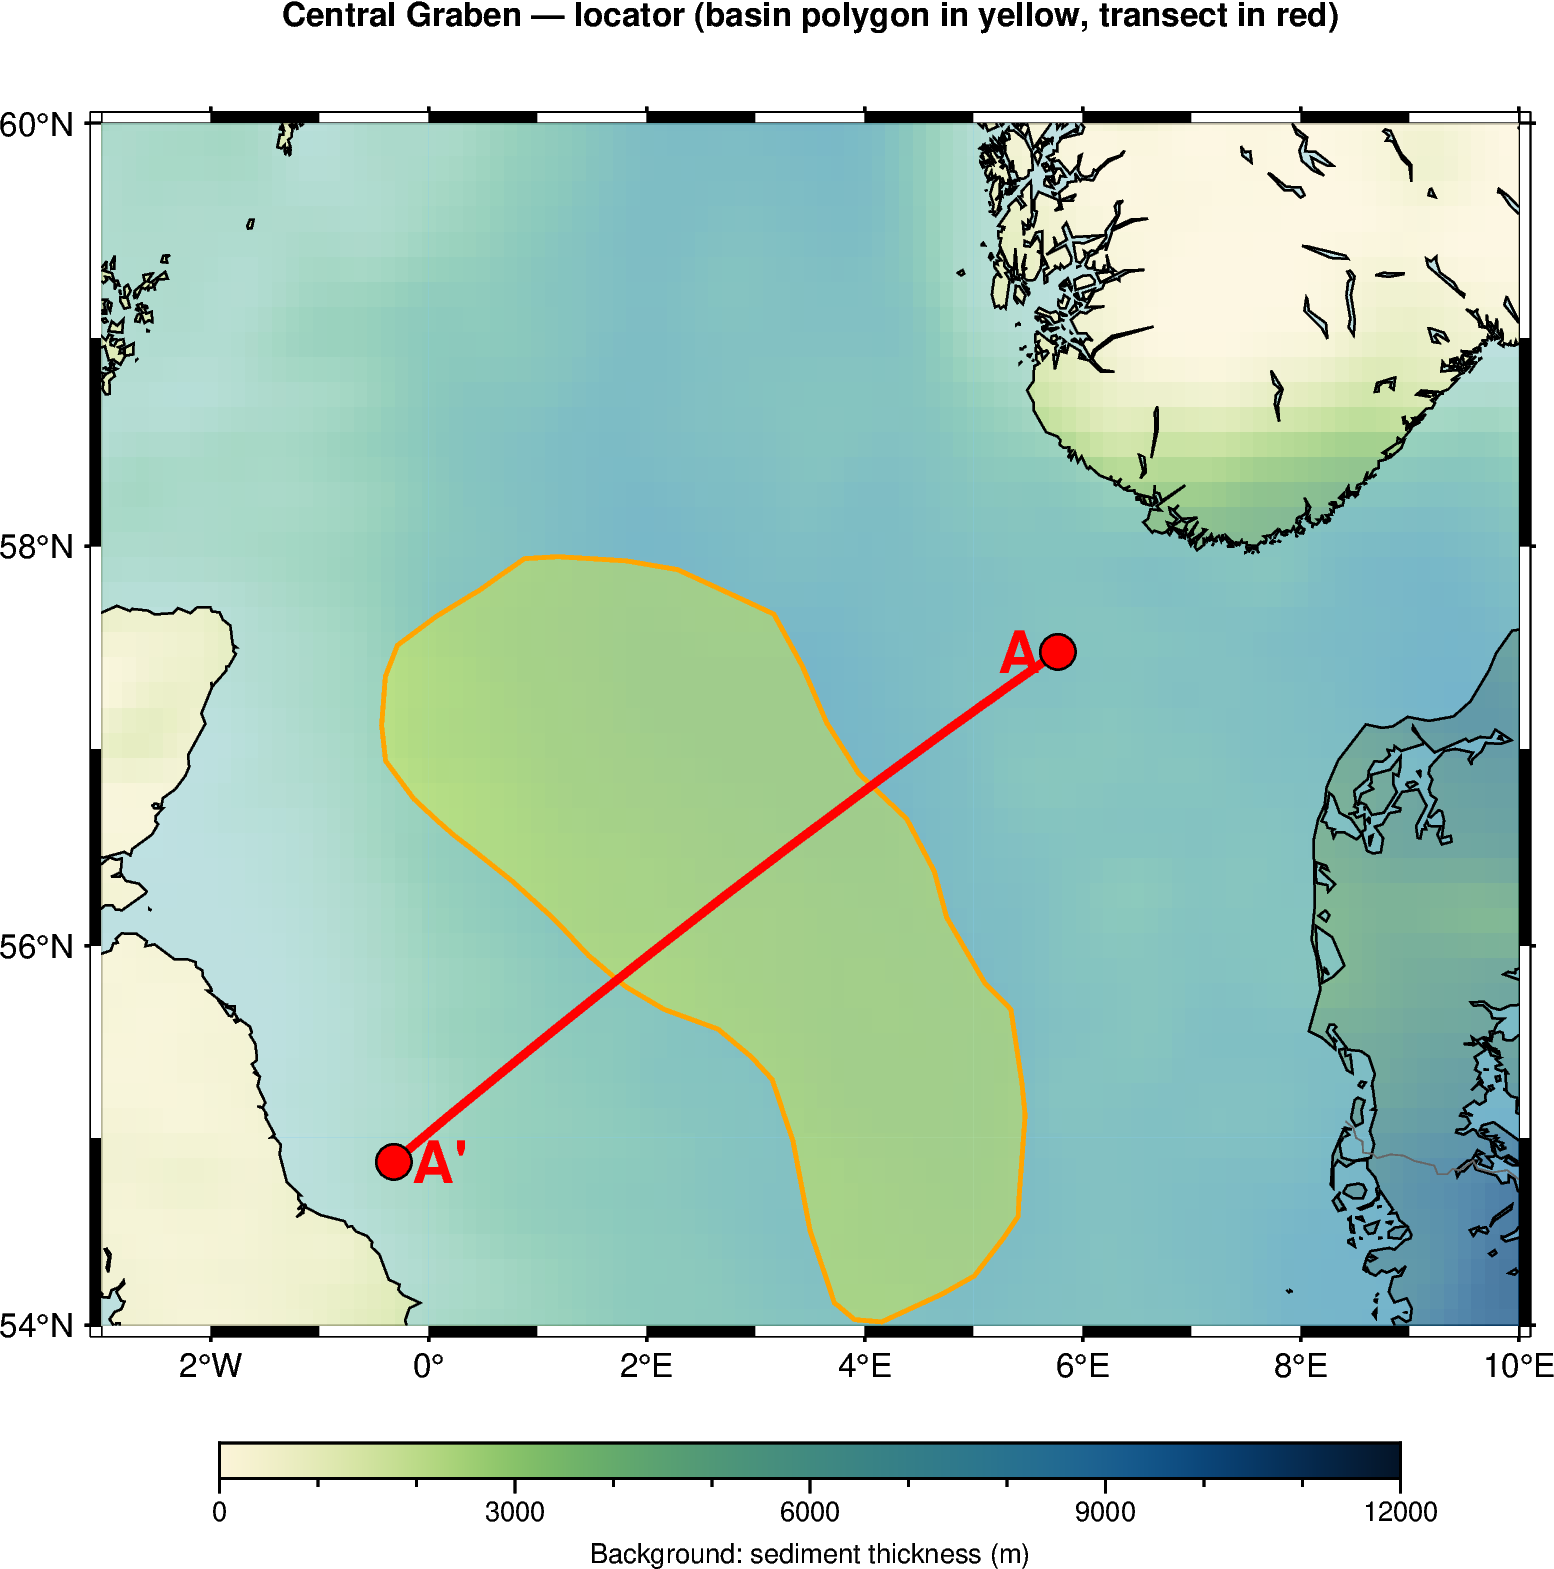

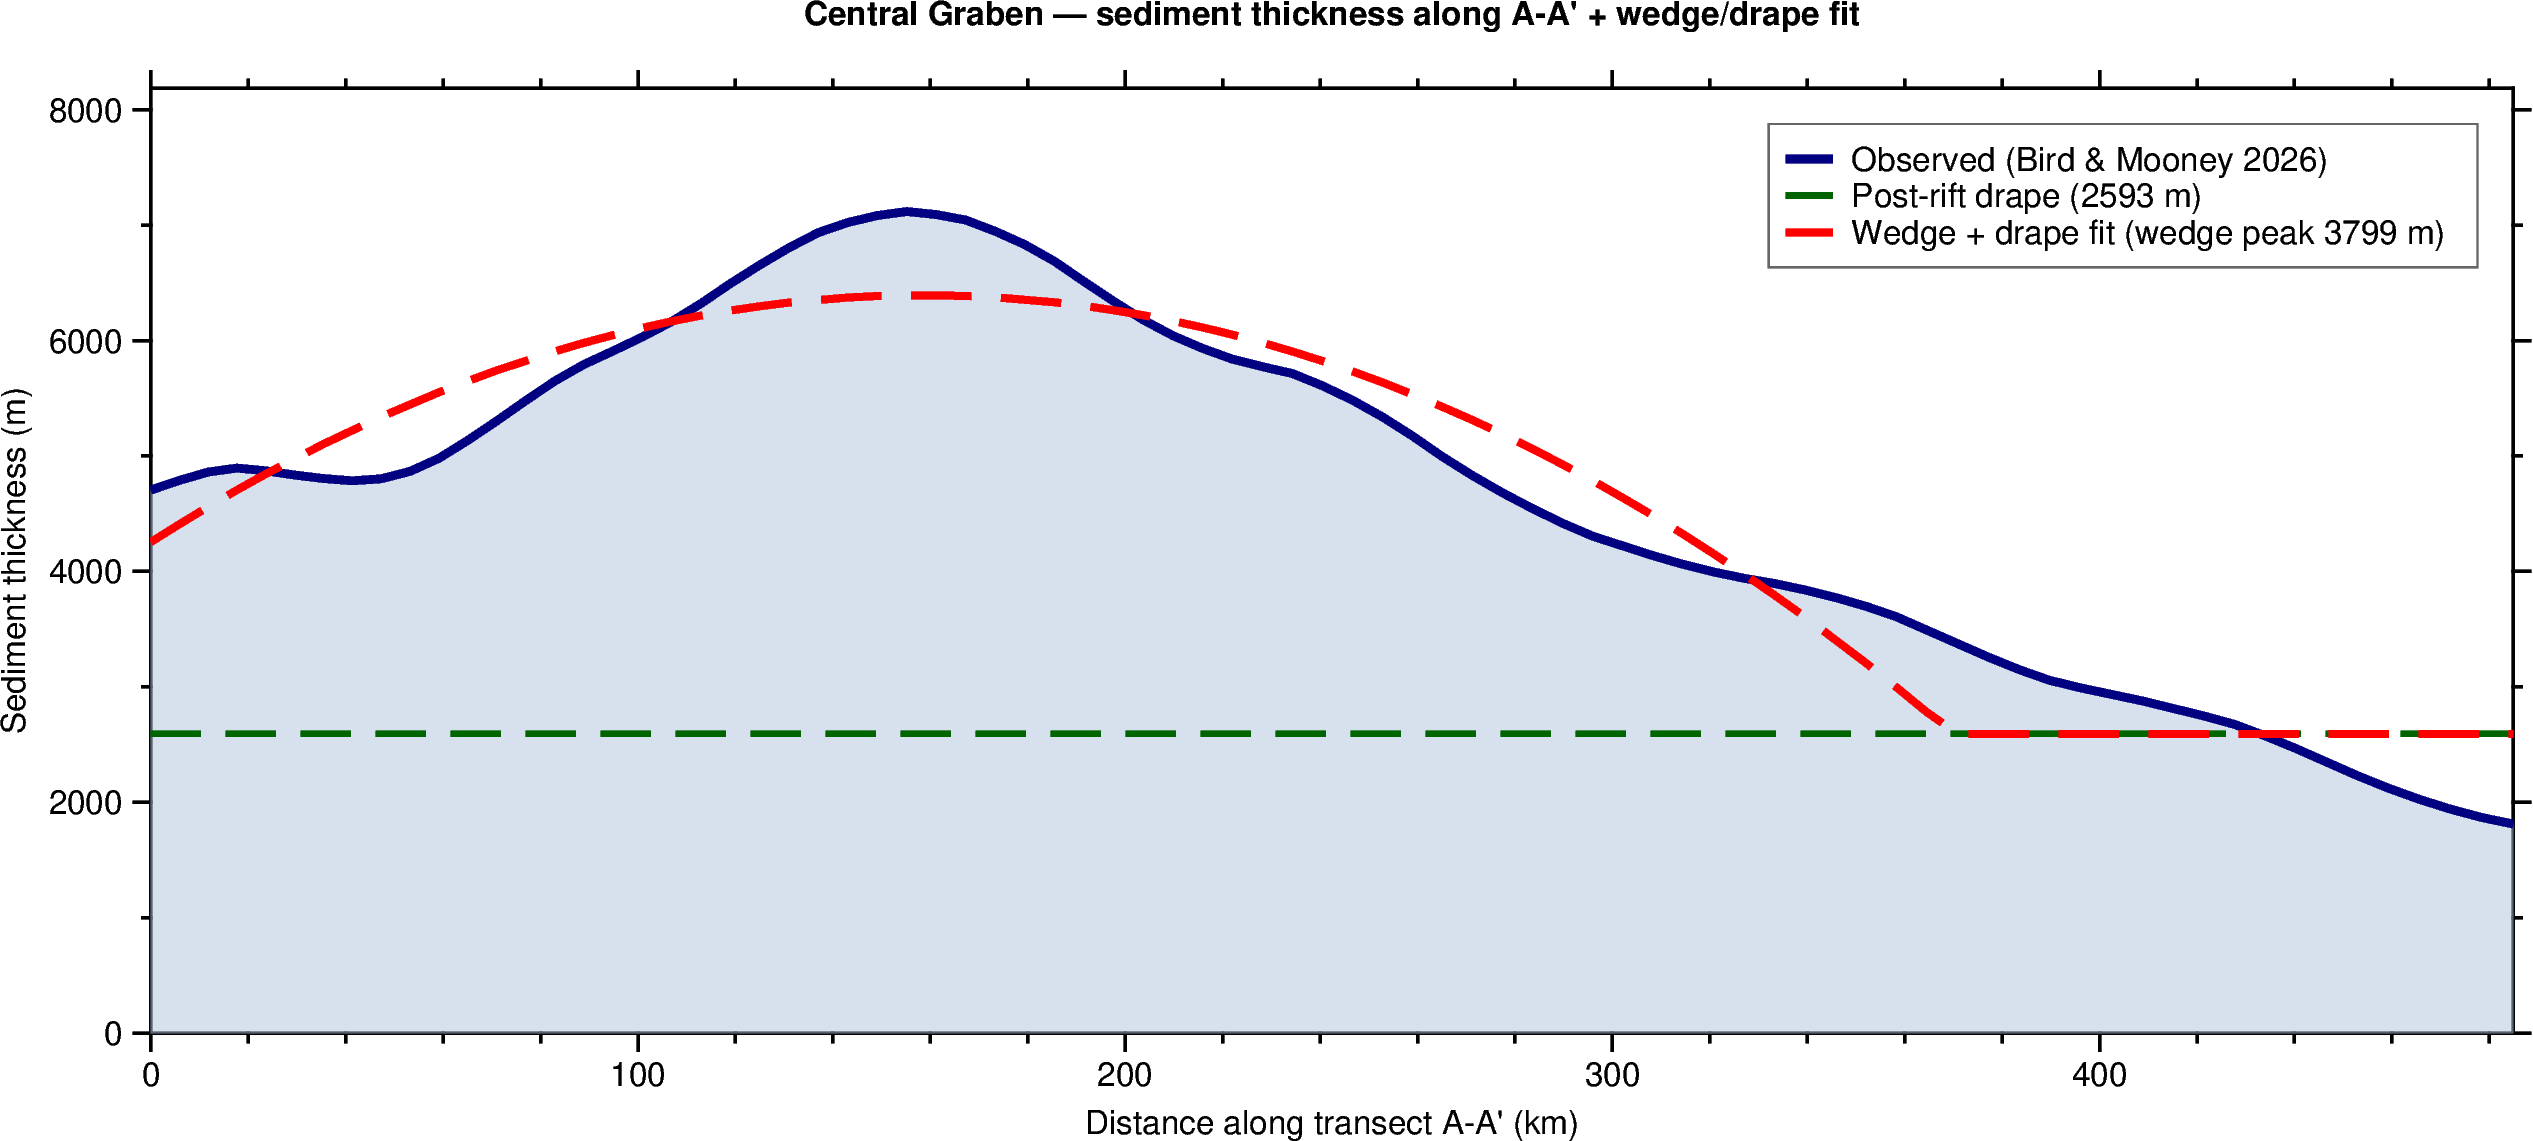

grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


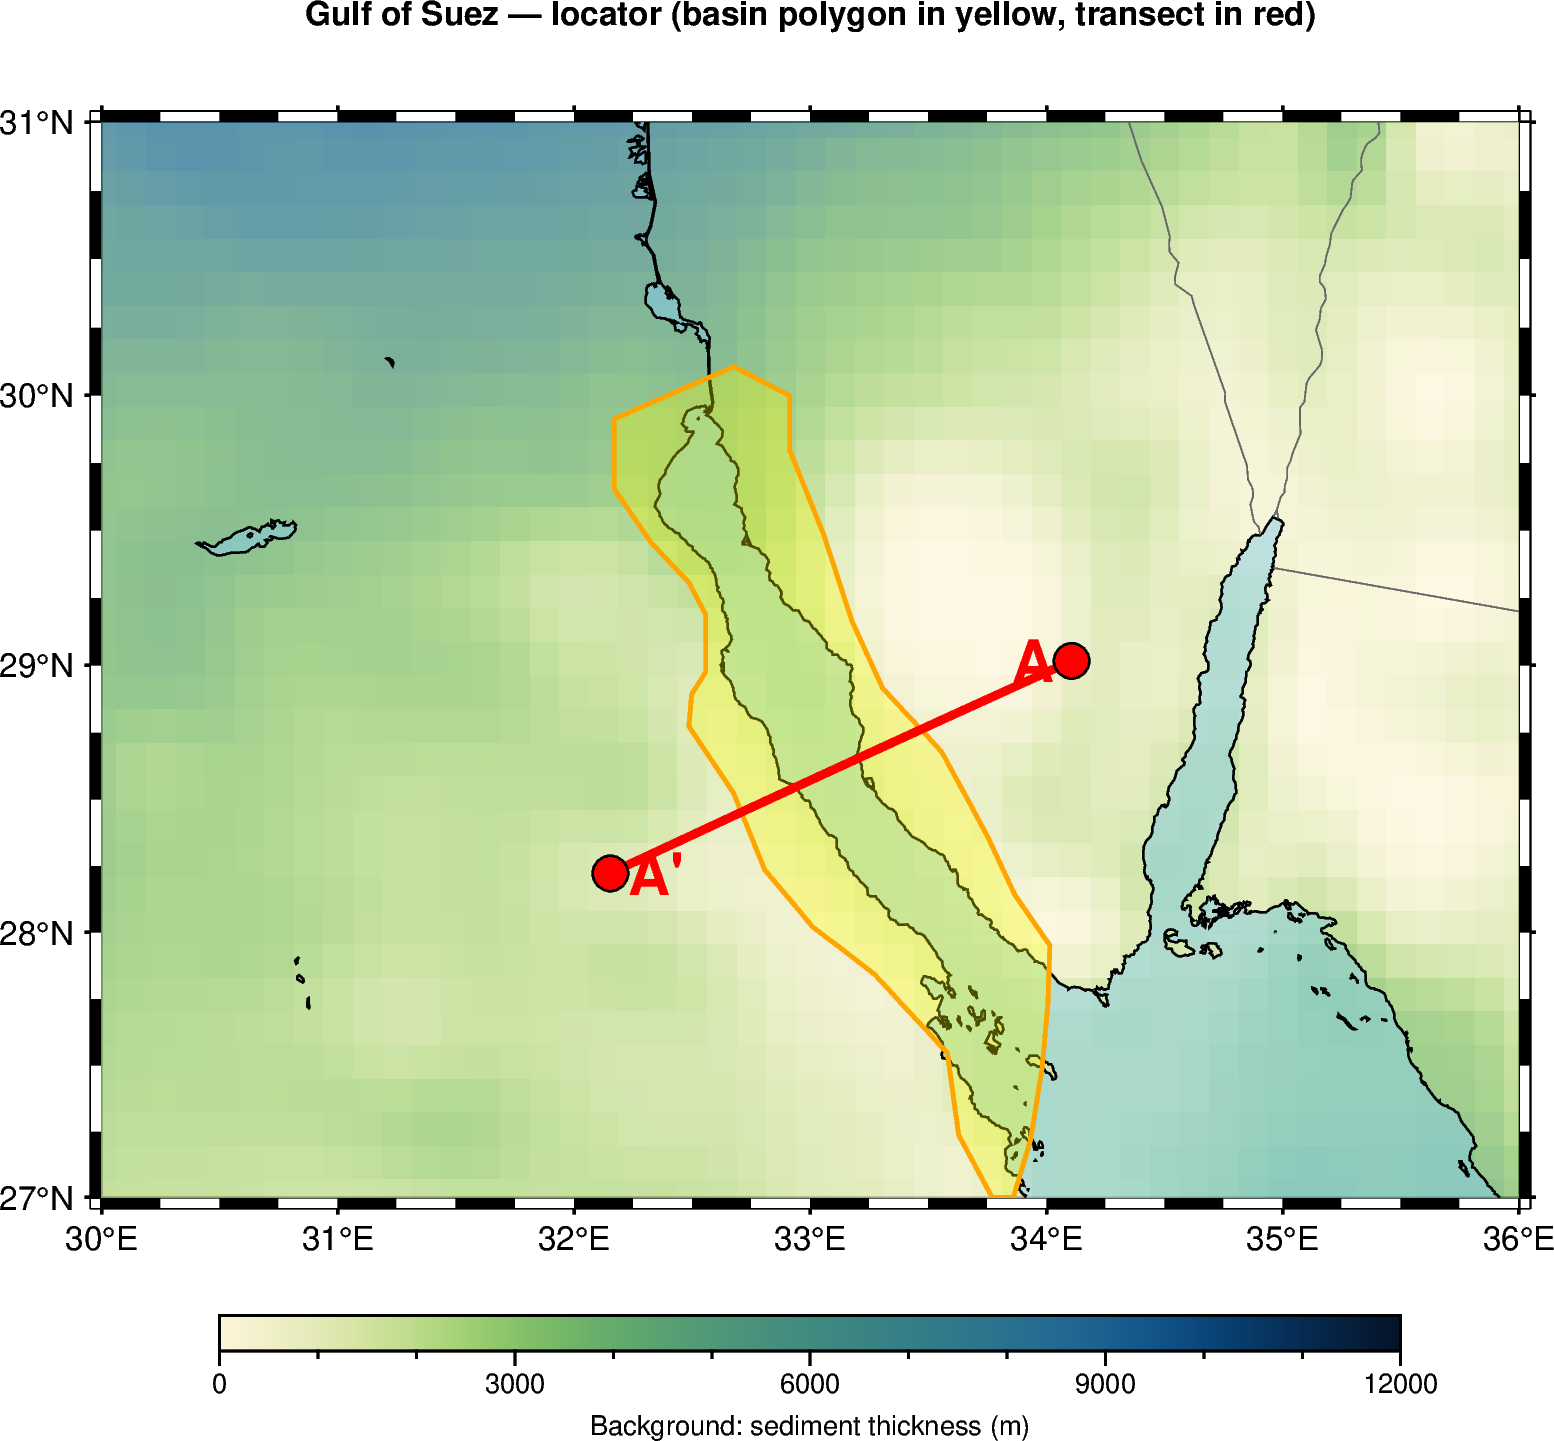

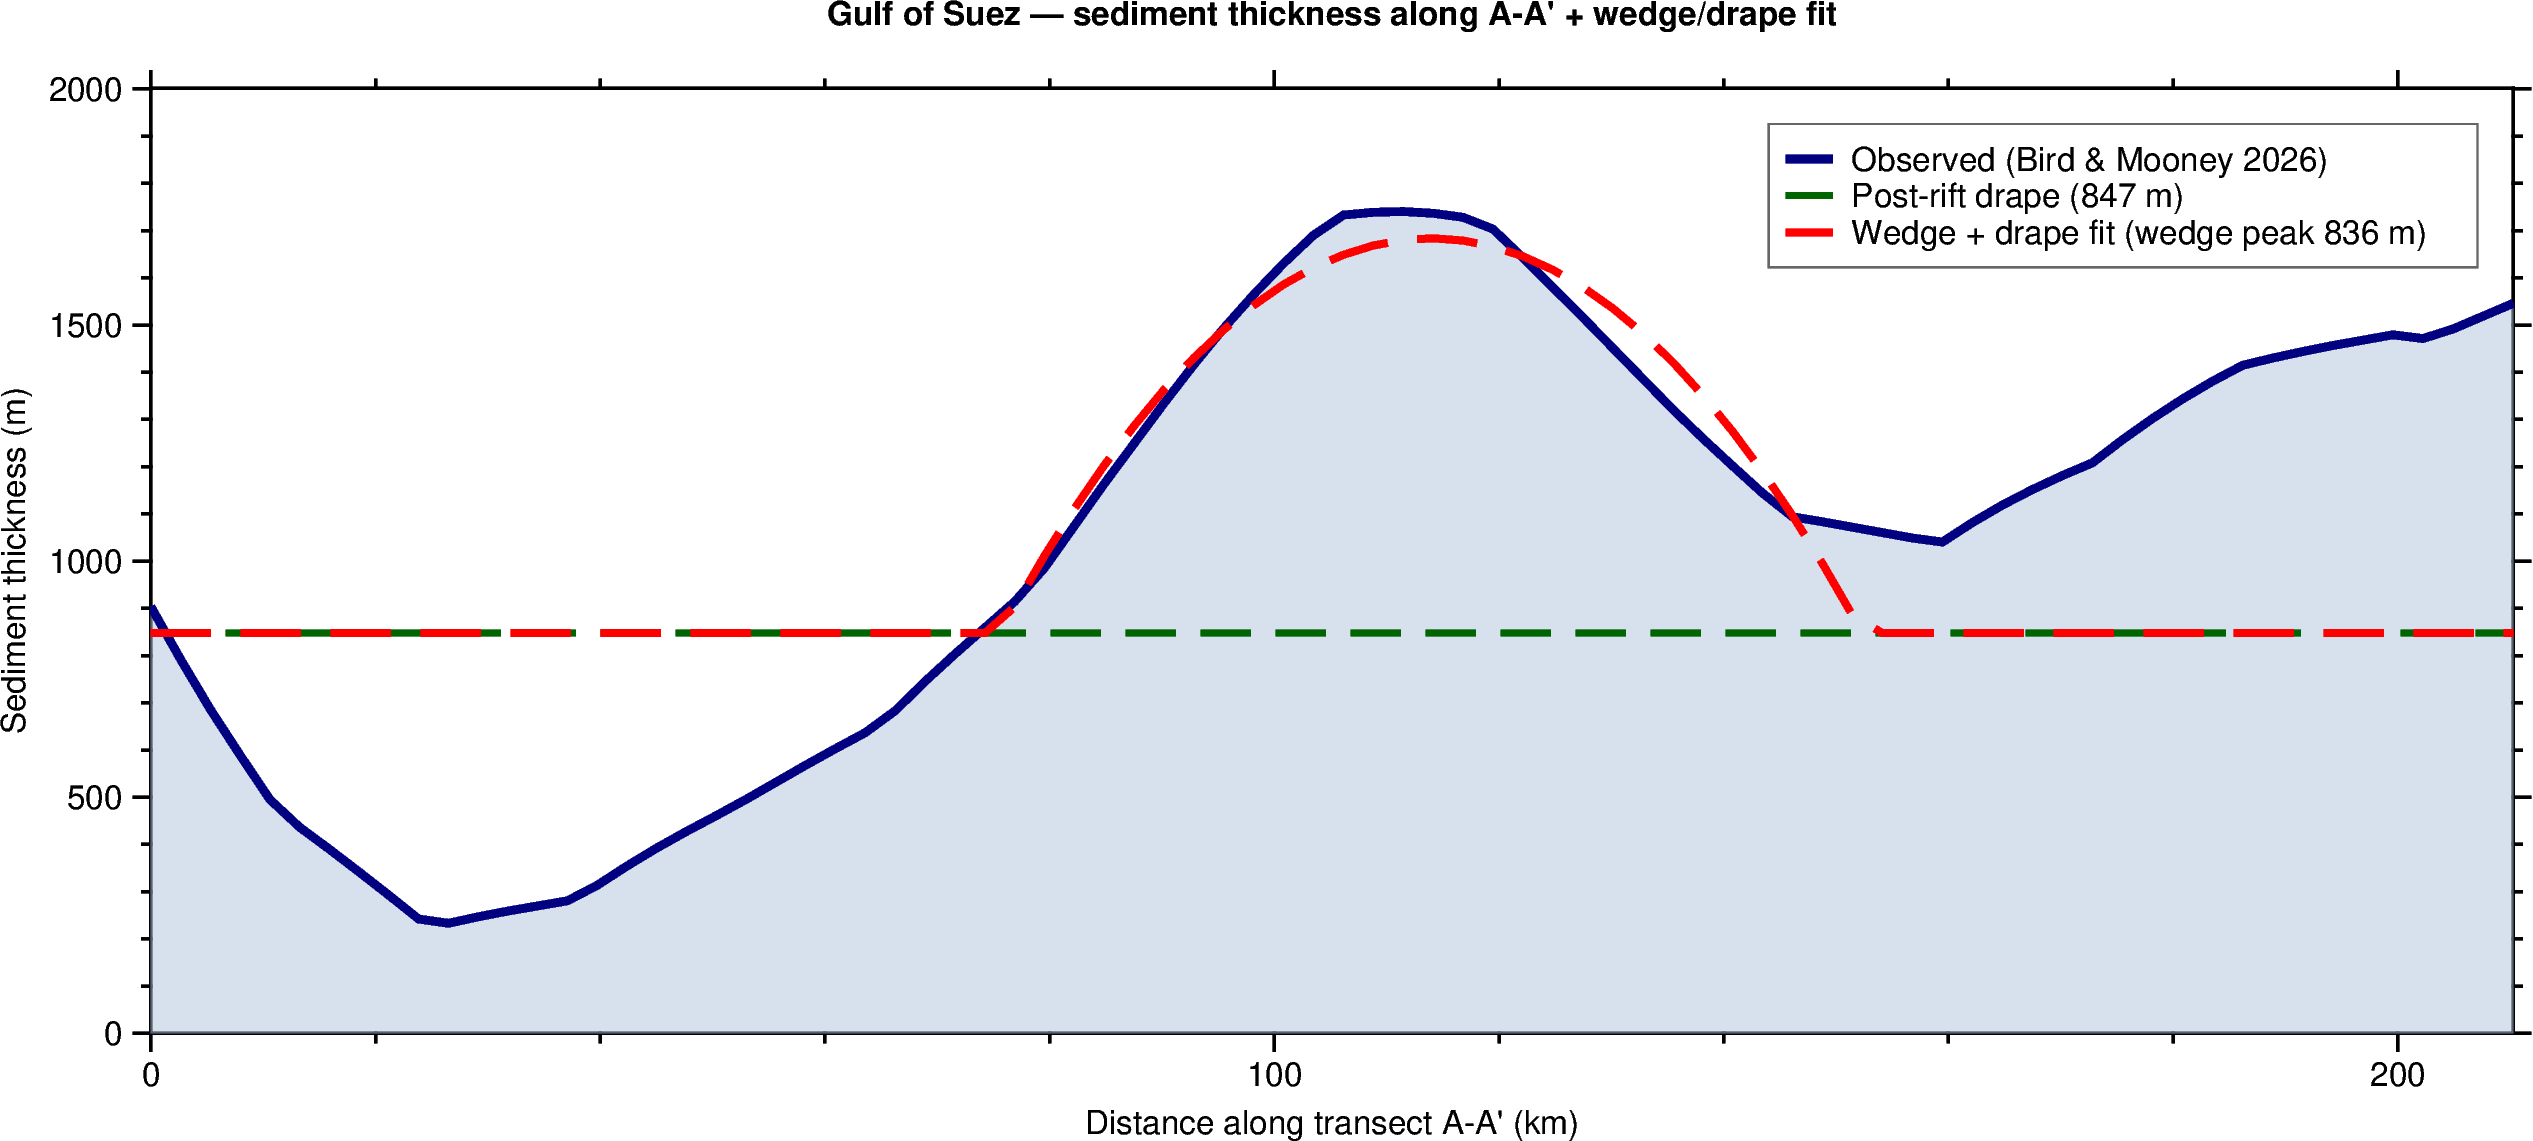

In [6]:
for r in results:
    case, basin = r["case"], r["basin"]
    (x1, y1), (x2, y2) = case.get("_transect", case.get("transect_pts"))

    # ---- Panel 4A: locator map ----
    fig = pygmt.Figure()
    fig.basemap(region=case["map_region"], projection=case["map_proj"],
                frame=["af", f"WSne+t{case['name']} — locator (basin polygon in yellow, transect in red)"])
    # Regional sediment-thickness background as a soft context layer
    pygmt.makecpt(cmap="navia", series=[0, 12000, 200], reverse=True, continuous=True)
    fig.grdimage(grid=sed_da, cmap=True, nan_transparent=True, transparency=25)
    fig.coast(shorelines="0.5p,black", borders=["1/0.3p,gray40"], water="skyblue@50")
    # Basin polygon
    g = basin.geometry
    parts = g.geoms if g.geom_type == "MultiPolygon" else [g]
    for part in parts:
        xs, ys = part.exterior.xy
        fig.plot(x=list(xs), y=list(ys), fill="yellow@70",
                 pen="1p,orange", close=True)
    # Transect
    fig.plot(x=[x1, x2], y=[y1, y2], pen="2p,red")
    fig.plot(x=[x1, x2], y=[y1, y2], style="c0.3c", fill="red", pen="0.5p,black")
    fig.text(x=x1, y=y1, text="A", justify="MR", offset="-0.15c/0c",
             font="14p,Helvetica-Bold,red")
    fig.text(x=x2, y=y2, text="A'", justify="ML", offset="0.15c/0c",
             font="14p,Helvetica-Bold,red")
    fig.colorbar(frame=["a3000f1000", "x+lBackground: sediment thickness (m)"],
                 position="JBC+w10c/0.3c+h+o0/1c")
    fig.show(width=900)

    # ---- Panel 4B: transect profile + wedge/drape fit ----
    d = r["dist_km"]
    obs = np.nan_to_num(r["sed_m"], nan=0.0)
    fit = r["fit"]
    fitted = wedge_plus_drape(d, fit["x_c"], fit["half_width_km"],
                              fit["wedge_peak_m"], fit["drape_m"])
    wedge_only = np.maximum(0, fit["wedge_peak_m"] * (1 - ((d - fit["x_c"]) / fit["half_width_km"]) ** 2))
    drape_only = np.full_like(d, fit["drape_m"])

    y_max = max(obs.max(), fitted.max()) * 1.15
    fig = pygmt.Figure()
    fig.basemap(region=[0, d.max(), 0, y_max],
                projection="X20c/8c",
                frame=["xa100f20+lDistance along transect A-A' (km)",
                       "yaf+lSediment thickness (m)",
                       f"WSne+t{case['name']} — sediment thickness along A-A' + wedge/drape fit"])
    # Observed (Bird & Mooney) — filled area under
    fig.plot(x=np.concatenate([d, d[::-1]]),
             y=np.concatenate([obs, np.zeros_like(obs)]),
             fill="lightsteelblue", pen=None, close=True, transparency=50)
    fig.plot(x=d, y=obs, pen="2p,navy", label="Observed (Bird & Mooney 2026)")
    # Drape
    fig.plot(x=d, y=drape_only, pen="1.5p,darkgreen,dashed",
             label=f"Post-rift drape ({fit['drape_m']:.0f} m)")
    # Fitted total
    fig.plot(x=d, y=fitted, pen="1.8p,red,dashed",
             label=f"Wedge + drape fit (wedge peak {fit['wedge_peak_m']:.0f} m)")
    fig.legend(position="JTR+jTR+o0.3c/0.3c+w6c",
               box="+gwhite+p0.4p,gray40")
    fig.show(width=1000)


## 5. McKenzie subsidence curves — theoretical, per basin

For each basin's estimated β (from Afonso crustal thickness at the centroid), plot the McKenzie 1978 prediction: instantaneous syn-rift subsidence (dashed vertical drop at time = rift_age_ma), then exponentially-decaying thermal subsidence over the following myr. The observed total sediment thickness on the transect at the basin's midpoint is plotted as a horizontal dashed line at time = 0 for comparison — a good fit means the sediment thickness roughly equals the accumulated subsidence at the basin's age.

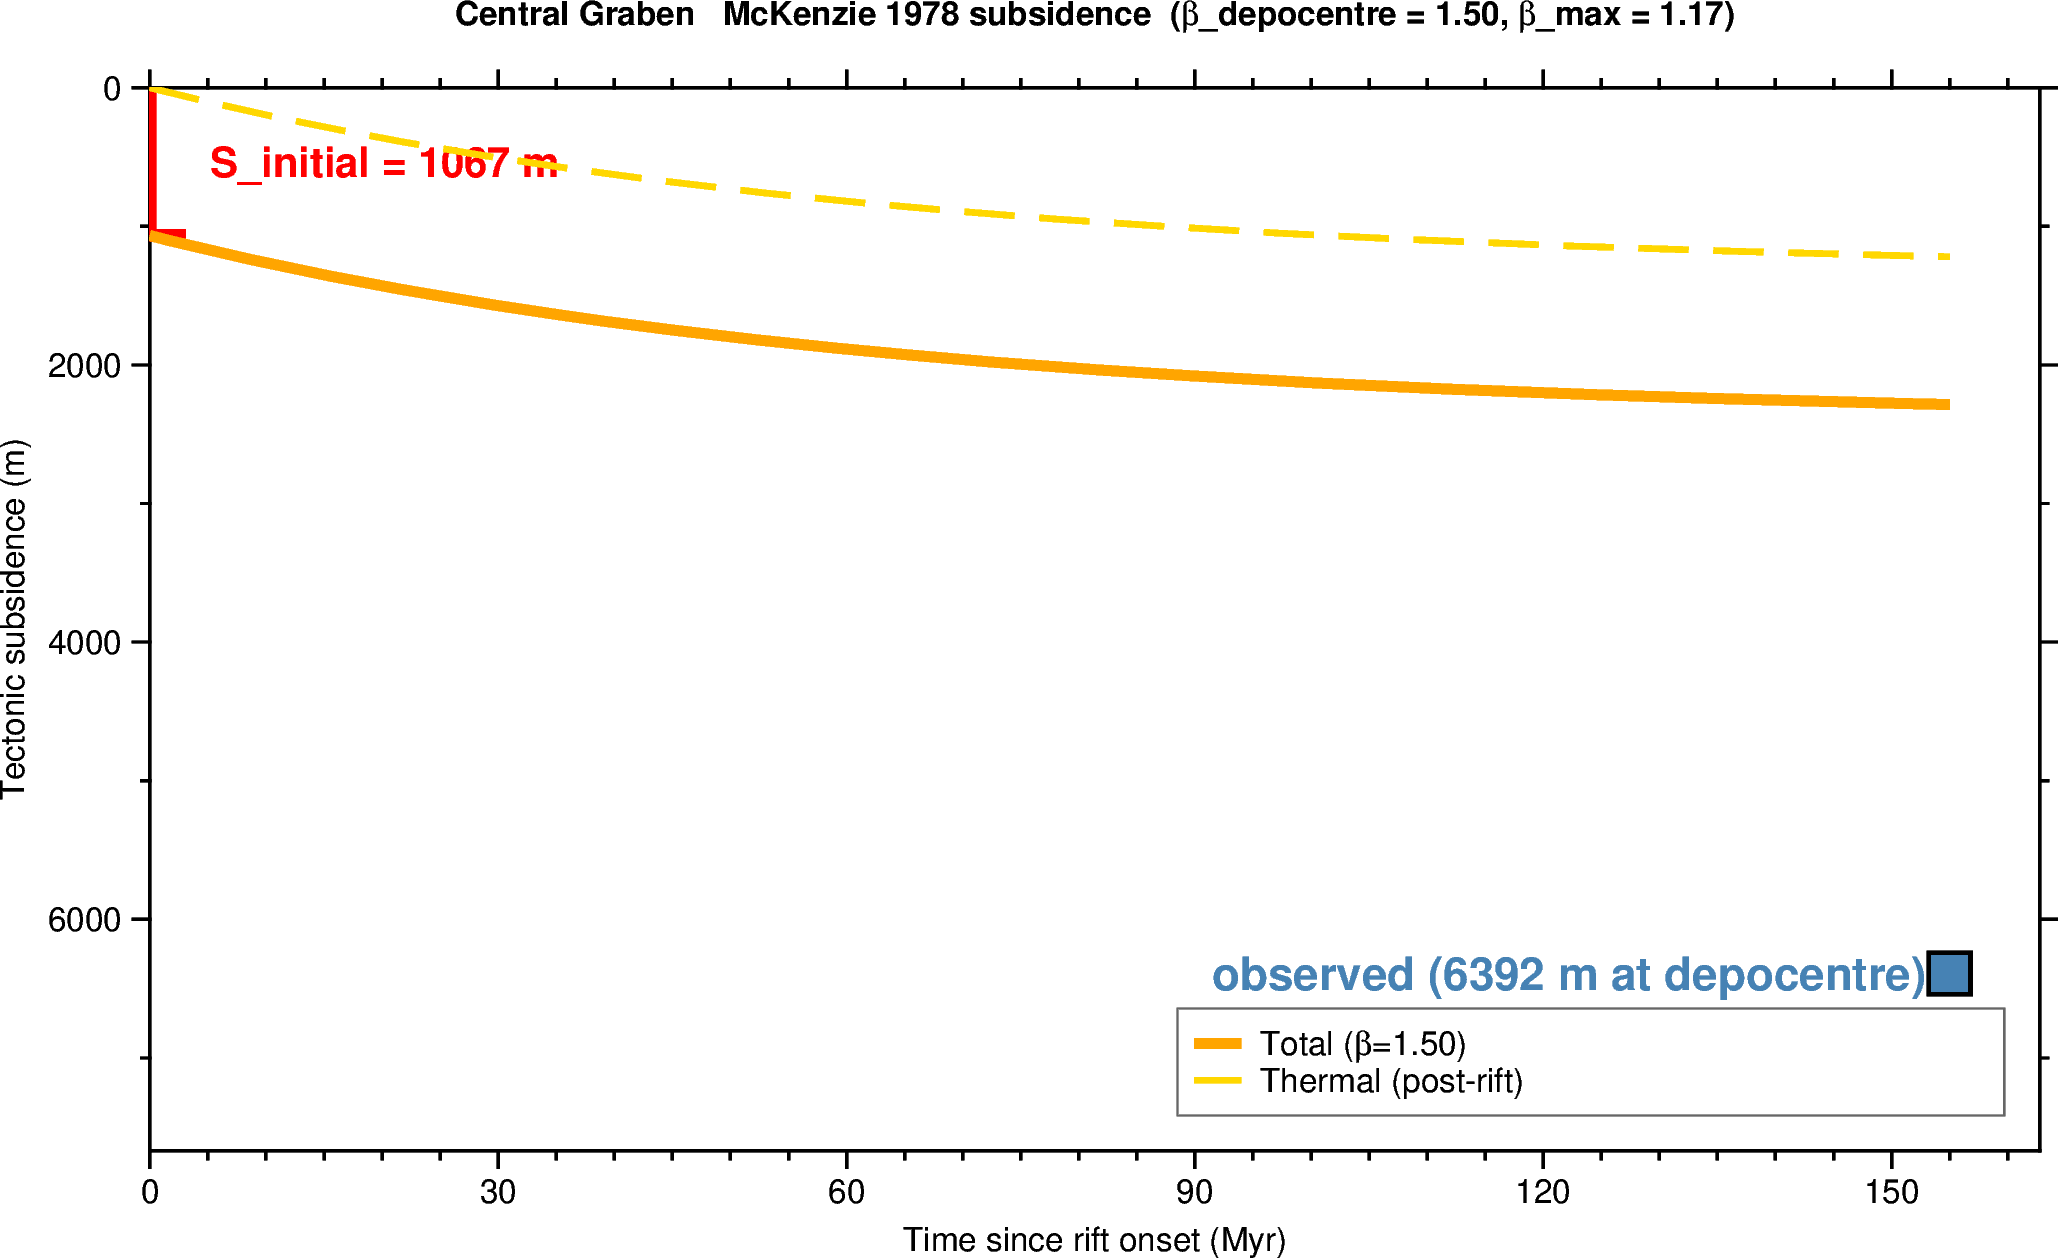

  Central Graben:
    β at depocentre   = 1.50   →  S_initial = 1067 m,  S_thermal(now) = 1219 m,  S_total(now) = 2285 m
    observed sed thk  = 6392 m at depocentre
    observed / predicted misfit = +180%
      → observed exceeds predicted by 180% — implies dynamic
        topography contribution and/or βmax closer to 1.17


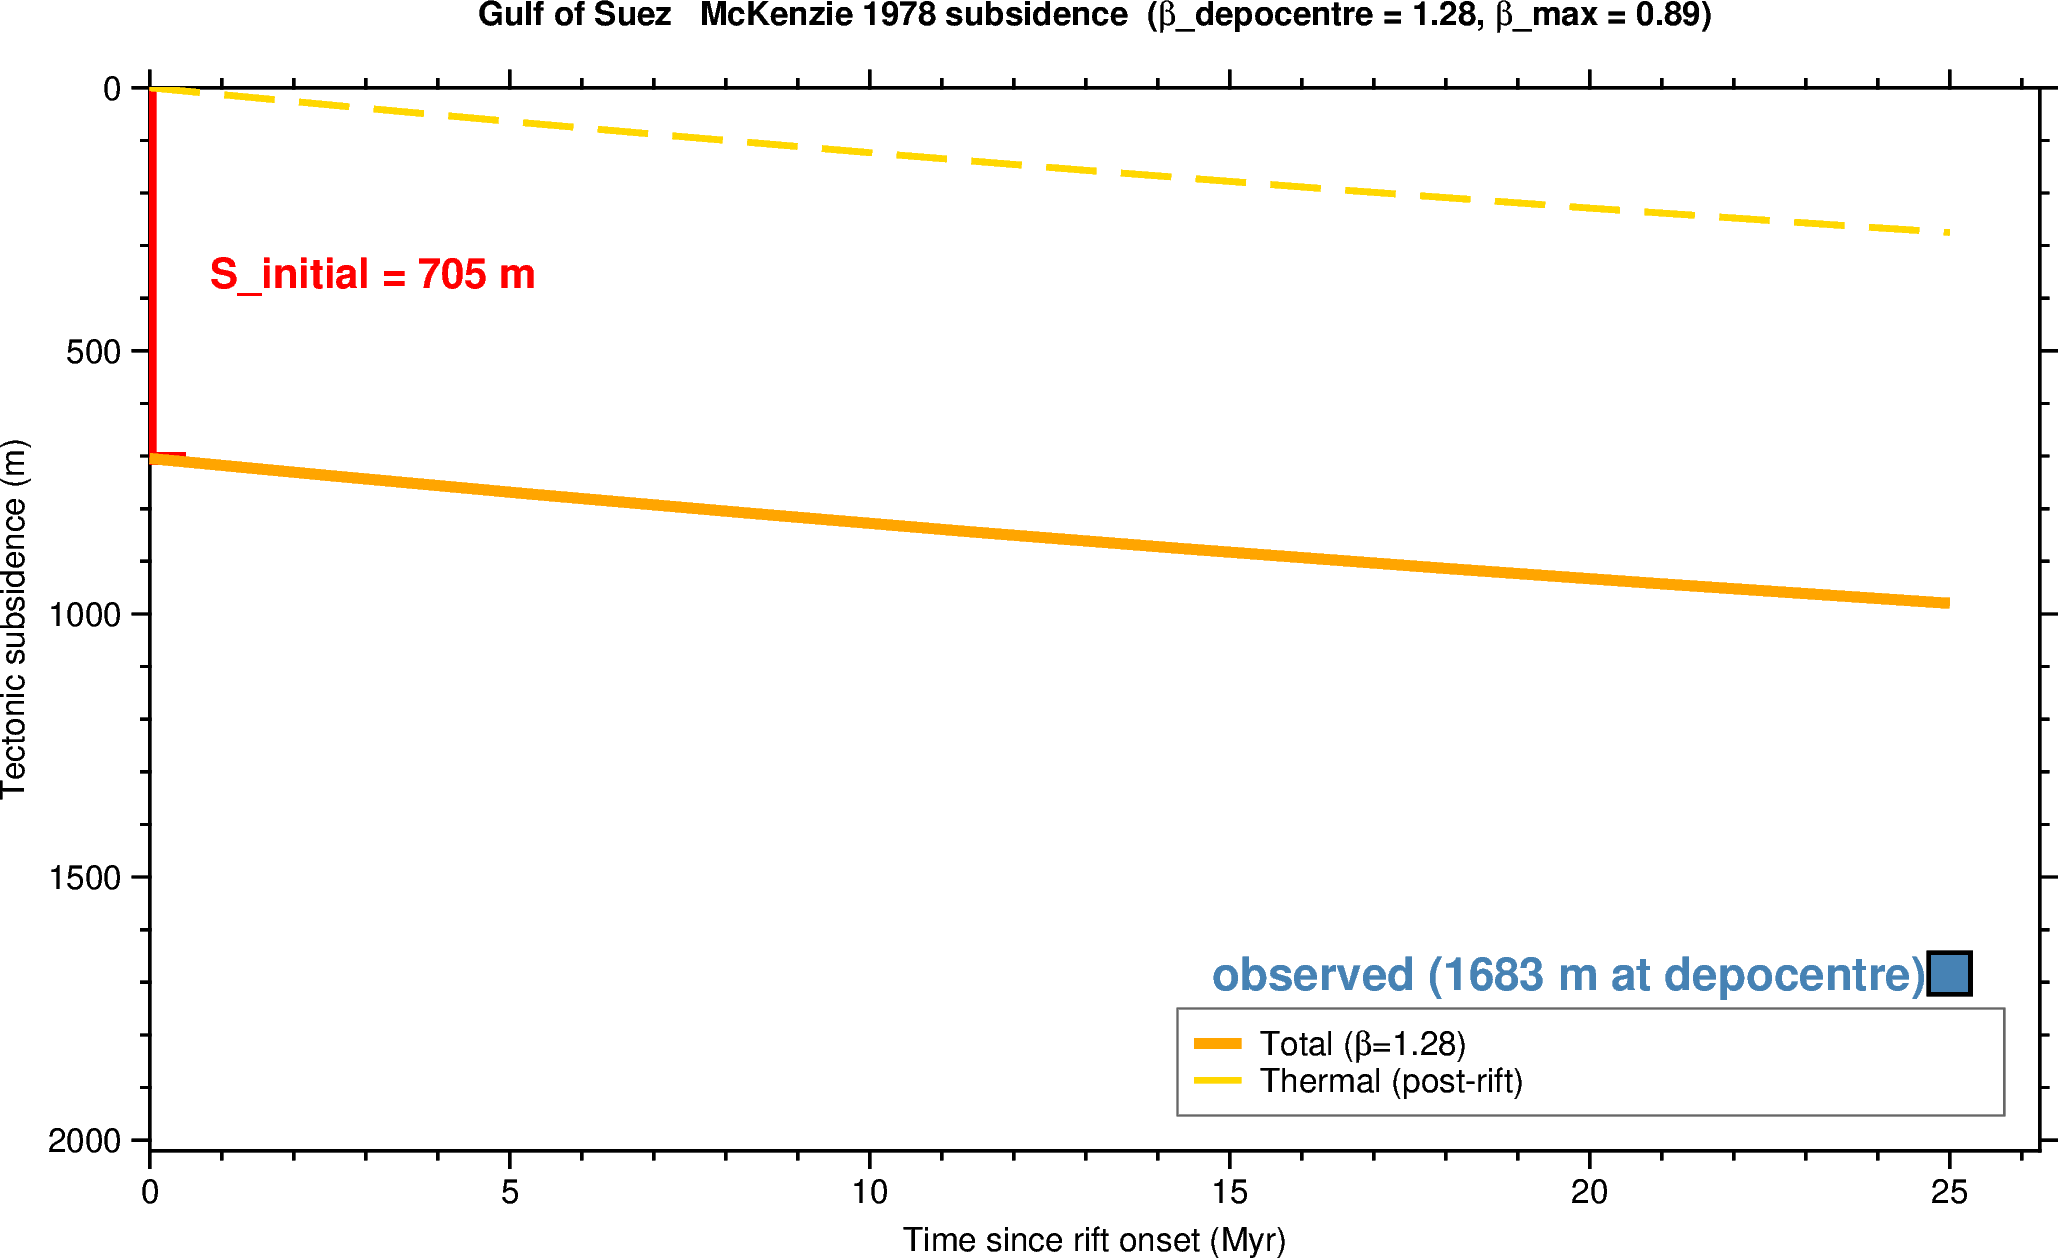

  Gulf of Suez:
    β at depocentre   = 1.28   →  S_initial = 705 m,  S_thermal(now) = 275 m,  S_total(now) = 980 m
    observed sed thk  = 1683 m at depocentre
    observed / predicted misfit = +72%
      → observed exceeds predicted by 72% — implies dynamic
        topography contribution and/or βmax closer to 0.89


In [7]:
for r in results:
    case = r["case"]
    beta = r["beta"]                                    # β at wedge-peak depocentre
    beta_max = r.get("beta_max", beta)
    t_myr = np.linspace(0, case["rift_age_ma"], 200)
    S_i    = initial_subsidence(beta)
    S_t    = thermal_subsidence(beta, t_myr)
    S_total = S_i + S_t                                  # cumulative
    # Compare to observed sediment thickness AT THE DEPOCENTRE
    obs_at_axis = float(r["fit"]["wedge_peak_m"] + r["fit"]["drape_m"])

    # Also compute the βmax bracket (thinnest crust on transect) for shading
    S_i_max = initial_subsidence(beta_max)
    S_t_max = thermal_subsidence(beta_max, t_myr)
    S_total_max = S_i_max + S_t_max

    # Y limit: whichever is larger — the βmax total curve or the observed
    y_max = max(S_total_max.max(), obs_at_axis) * 1.20

    fig = pygmt.Figure()
    # Adaptive x-axis annotation interval: short rifts (Gulf of Suez, 25 Ma)
    # need tick spacing of 5 Myr; long rifts (Central Graben, 155 Ma) can
    # afford 30 Myr. Rule of thumb — target ~6 major ticks across the frame.
    _rift_yr = case["rift_age_ma"]
    if   _rift_yr <=  30: _xa, _xf = 5,   1
    elif _rift_yr <=  60: _xa, _xf = 10,  2
    elif _rift_yr <= 120: _xa, _xf = 20,  5
    else:                 _xa, _xf = 30,  5
    fig.basemap(region=[0, _rift_yr * 1.05, 0, y_max],
                projection="X16c/-9c",
                frame=[f"xa{_xa}f{_xf}+lTime since rift onset (Myr)",
                       "yaf+lTectonic subsidence (m)",
                       f"WSne+t{case['name']}   McKenzie 1978 subsidence  "
                       f"(β_depocentre = {beta:.2f}, β_max = {beta_max:.2f})"])

    # --- Syn-rift instantaneous step at t=0 (depocentre β) ---
    fig.plot(x=[0, 0], y=[0, S_i], pen="3p,red")
    # A small horizontal tick at the top of the step so it reads visually
    fig.plot(x=[0, case["rift_age_ma"] * 0.02], y=[S_i, S_i], pen="3p,red")
    fig.text(x=case["rift_age_ma"] * 0.03, y=S_i * 0.5,
             text=f"S_initial\n= {S_i:.0f} m", justify="ML", offset="0.05c/0c",
             font="10p,Helvetica-Bold,red")

    # --- Total subsidence (S_i + S_t) for depocentre β ---
    fig.plot(x=t_myr, y=S_i + S_t, pen="2.5p,orange",
             label=f"Total (β={beta:.2f})")
    # --- Thermal-only component ---
    fig.plot(x=t_myr, y=S_t, pen="1.5p,gold,dashed",
             label="Thermal (post-rift)")

    # --- Observed sediment thickness AT THE DEPOCENTRE (as a marker at t=rift_age) ---
    fig.plot(x=[case["rift_age_ma"]], y=[obs_at_axis],
             style="s0.5c", fill="steelblue", pen="1p,black")
    fig.text(x=case["rift_age_ma"], y=obs_at_axis, justify="MR",
             offset="-0.2c/0c",
             text=f"observed ({obs_at_axis:.0f} m at depocentre)",
             font="11p,Helvetica-Bold,steelblue")

    # Legend
    fig.legend(position="JBR+jBR+o0.3c/0.3c+w7c",
               box="+gwhite+p0.4p,gray40")
    fig.show(width=1000)

    # Diagnostic print — what should the reader compare?
    _predicted_now = S_i + thermal_subsidence(beta, case["rift_age_ma"])
    print(f"  {case['name']}:")
    print(f"    β at depocentre   = {beta:.2f}   →  S_initial = {S_i:.0f} m,  "
          f"S_thermal(now) = {thermal_subsidence(beta, case['rift_age_ma']):.0f} m,  "
          f"S_total(now) = {_predicted_now:.0f} m")
    print(f"    observed sed thk  = {obs_at_axis:.0f} m at depocentre")
    _misfit = (obs_at_axis - _predicted_now) / _predicted_now * 100 if _predicted_now > 10 else np.nan
    if np.isfinite(_misfit):
        print(f"    observed / predicted misfit = {_misfit:+.0f}%")
        if _misfit > 25:
            print(f"      → observed exceeds predicted by {_misfit:.0f}% — implies dynamic")
            print(f"        topography contribution and/or βmax closer to {beta_max:.2f}")
        elif _misfit < -25:
            print(f"      → observed under-fills predicted by {abs(_misfit):.0f}% — sediment-starved basin")


## 6a. Extended per-basin analysis — stretching-factor and subsidence-budget parameter set

Beyond the wedge/drape decomposition + McKenzie curves shown above, this section computes an extended set of basin parameters that isolate different signals — crustal versus sedimentary stretching, tectonic versus loading subsidence, and the anomalous residual which flags either mantle dynamic-topography contribution or hyper-extension.

The block below extracts, per basin:

- **βcrust** — McKenzie stretching factor from Afonso crustal thickness at basin centre.
- **βsed**  — stretching factor implied by the total sediment thickness (via Airy isostasy of a sediment-filled basin).
- **βlith** — stretching factor of the lithospheric column, assuming pure shear (= βcrust for pure shear; differs for depth-dependent stretching).
- **TTScrust** — tectonic subsidence expected from crustal thinning alone.
- **TTSsed**  — tectonic subsidence implied by the sediment load (backstripped, air-loaded equivalent).
- **anotts** — anomalous tectonic subsidence (TTSsed − TTScrust) — a positive value flags either dynamic-topography subsidence or hyper-extension not captured by the crustal thickness.
- **diffbeta** — βsed − βcrust — same signal as anotts but expressed as a stretching-factor difference.
- **isocorr** — Airy isostatic correction (basement rebound if all sediment were removed).
- **basin area (km²)**, **max fill (km)**, **transect basin length (km)**, **extension (km)** — geometric.


In [8]:
# Extended-parameter helpers — stretching-factor and subsidence-budget suite

RHO_SED_AVG      = 2350.0    # average sediment density including compaction (kg/m³)
RHO_C_UNSTR      = 2800.0    # unstretched continental crust density
RHO_M_STD        = 3300.0    # mantle
RHO_W_STD        = 1030.0    # seawater

def beta_from_sediment(sed_thk_m: float) -> float:
    """β implied by sediment loading, assuming Airy isostasy and a sediment-
    filled (water-free) basin. Solves: sediment column S_sed = S_i(β) *
    (ρ_m - ρ_w) / (ρ_m - ρ_sed). Rearrange for β given S_sed."""
    if sed_thk_m <= 0:
        return 1.0
    # Loading correction — a sediment-filled basin subsides more than an
    # air-filled one by factor (ρ_m - ρ_w) / (ρ_m - ρ_sed).
    S_i_equiv = sed_thk_m * (RHO_M_STD - RHO_SED_AVG) / (RHO_M_STD - RHO_W_STD)
    # Solve S_initial(β) = S_i_equiv by scanning β on a fine grid.
    betas = np.linspace(1.001, 6.0, 500)
    S_pred = np.array([initial_subsidence(b) for b in betas])
    return float(betas[np.argmin(np.abs(S_pred - S_i_equiv))])

def tts_from_crustal_thinning(beta: float) -> float:
    """Tectonic subsidence from pure-shear crustal thinning alone — the
    initial (syn-rift) portion of the McKenzie budget. Metres, air-loaded."""
    return initial_subsidence(beta)

def tts_from_sediment(sed_thk_m: float) -> float:
    """Tectonic subsidence backstripped from the observed sediment column,
    Airy-loaded conversion (sediment fill → equivalent air-loaded subsidence)."""
    if sed_thk_m <= 0:
        return 0.0
    return sed_thk_m * (RHO_M_STD - RHO_SED_AVG) / (RHO_M_STD - RHO_W_STD)

def airy_isostatic_correction(sed_thk_m: float) -> float:
    """Airy rebound if all sediment were removed — an isostatic correction
    used in basement-restoration workflows. Metres of uplift."""
    if sed_thk_m <= 0:
        return 0.0
    return sed_thk_m * (RHO_SED_AVG - RHO_W_STD) / (RHO_M_STD - RHO_W_STD)

def extension_km(basin_length_km: float, beta: float) -> float:
    """Total extension in km along the transect axis, given the basin's
    stretched length and its β. Extension = L * (1 - 1/β)."""
    return basin_length_km * (1 - 1 / beta)


## 6b. Compute the full parameter set for each basin


In [9]:
# For each result dict, compute all extended parameters.
extended_rows = []
for r in results:
    case, basin = r["case"], r["basin"]
    # Basin geometry
    dist_km = r["dist_km"]
    sed_arr = np.nan_to_num(r["sed_m"], nan=0.0)
    # Peak observed sediment along transect (proxy for basin-axis fill)
    sed_peak_m = float(sed_arr.max())
    # Basin width along transect: distance over which sed > 500 m (arbitrary)
    _in_basin = sed_arr > 500
    basin_len_km = float((dist_km[_in_basin].max() - dist_km[_in_basin].min())
                          if _in_basin.any() else 0.0)

    beta_crust = r["beta"]
    beta_sed   = beta_from_sediment(sed_peak_m)
    beta_lith  = beta_crust                       # pure-shear assumption

    tts_crust  = tts_from_crustal_thinning(beta_crust)
    tts_sed    = tts_from_sediment(sed_peak_m)
    anotts     = tts_sed - tts_crust
    diffbeta   = beta_sed - beta_crust
    isocorr    = airy_isostatic_correction(sed_peak_m)
    ext_km     = extension_km(basin_len_km, beta_crust)

    # Wedge/drape geometry (from previous fit)
    fit = r["fit"]
    wedge_area_m2 = (2.0 / 3.0) * fit["wedge_peak_m"] * (2 * fit["half_width_km"] * 1000)
    drape_area_m2 = fit["drape_m"] * (dist_km.max() * 1000)
    syn_post_ratio = wedge_area_m2 / (drape_area_m2 + 1e-6)

    row = {
        "basin":               basin["Basin Name"],
        "rift_age_Ma":         case["rift_age_ma"],
        "area_km2":            float(basin["Poly Area"]),
        "max_sed_st_orig":     float(basin["Max Sed St"]),
        "basin_type":          str(basin.get("Basin Type", "")),
        "tc_centre_km":        r["tc_centre"],
        "sed_peak_m":          sed_peak_m,
        "basin_len_km":        basin_len_km,
        "beta_crust":          beta_crust,
        "beta_sed":            beta_sed,
        "beta_lith":           beta_lith,
        "tts_crust_m":         tts_crust,
        "tts_sed_m":           tts_sed,
        "anotts_m":            anotts,
        "diffbeta":            diffbeta,
        "isocorr_m":           isocorr,
        "extension_km":        ext_km,
        "wedge_peak_m":        fit["wedge_peak_m"],
        "drape_m":             fit["drape_m"],
        "syn_post_area_ratio": syn_post_ratio,
    }
    extended_rows.append(row)

params_df = pd.DataFrame(extended_rows)
print(f"Extended parameter set for {len(params_df)} basins:\n")
with pd.option_context("display.max_columns", None,
                        "display.width", 200,
                        "display.float_format", "{:.2f}".format):
    print(params_df.T.to_string())


Extended parameter set for 2 basins:

                                     0             1
basin                Central North Sea  Gulf of Suez
rift_age_Ma                     155.00         25.00
area_km2                     142019.00      26596.00
max_sed_st_orig                   9.56          3.32
basin_type                        Rift          Rift
tc_centre_km                     27.69         37.89
sed_peak_m                     7115.08       1739.89
basin_len_km                    484.87        210.26
beta_crust                        1.50          1.28
beta_sed                          6.00          1.29
beta_lith                         1.50          1.28
tts_crust_m                    1066.80        704.51
tts_sed_m                      2977.68        728.15
anotts_m                       1910.87         23.63
diffbeta                          4.50          0.01
isocorr_m                      4137.40       1011.74
extension_km                    161.62         46.29
wedge_pe

## 6c. Cross-basin parameter comparison — bar chart of the key stretching-factor ratios

Same three quantities plotted side-by-side across all case-study basins:
**βcrust / βsed / diffbeta** (top), **TTScrust / TTSsed / anotts** (bottom).
A large positive **diffbeta** or **anotts** flags a basin whose sediment record
cannot be explained by crustal thinning alone — implying dynamic-topography
contribution, post-rift thermal subsidence, or depth-dependent stretching.


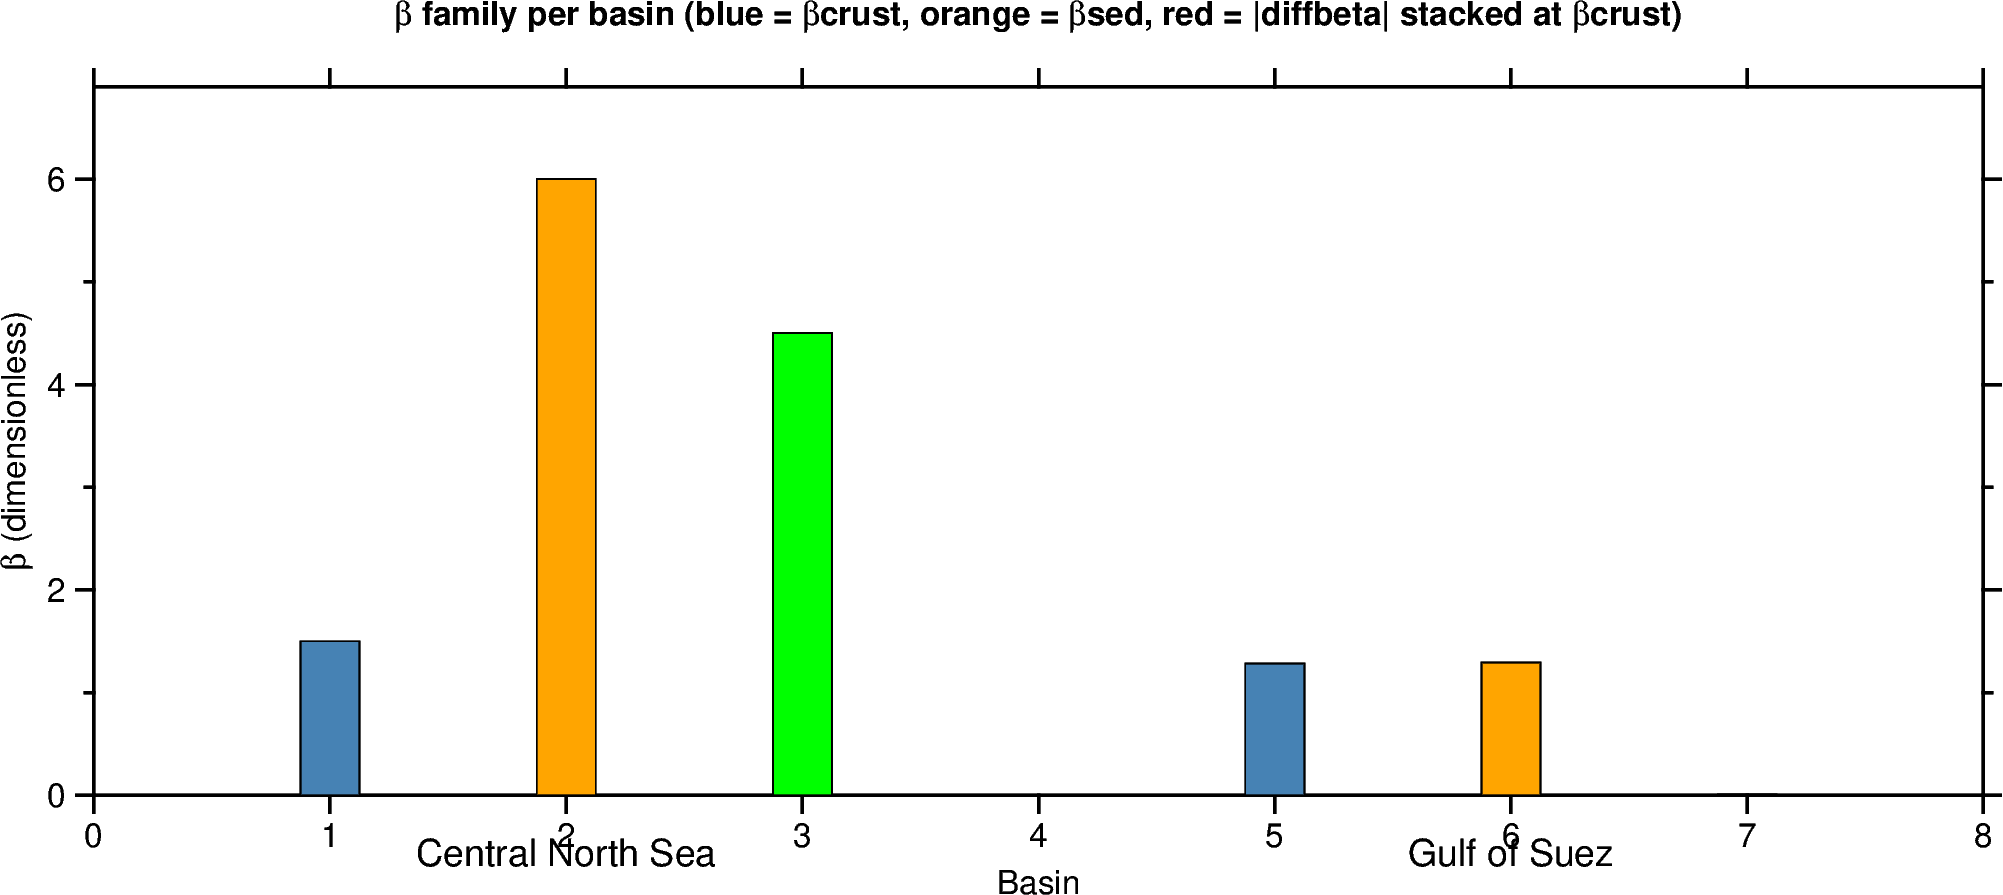

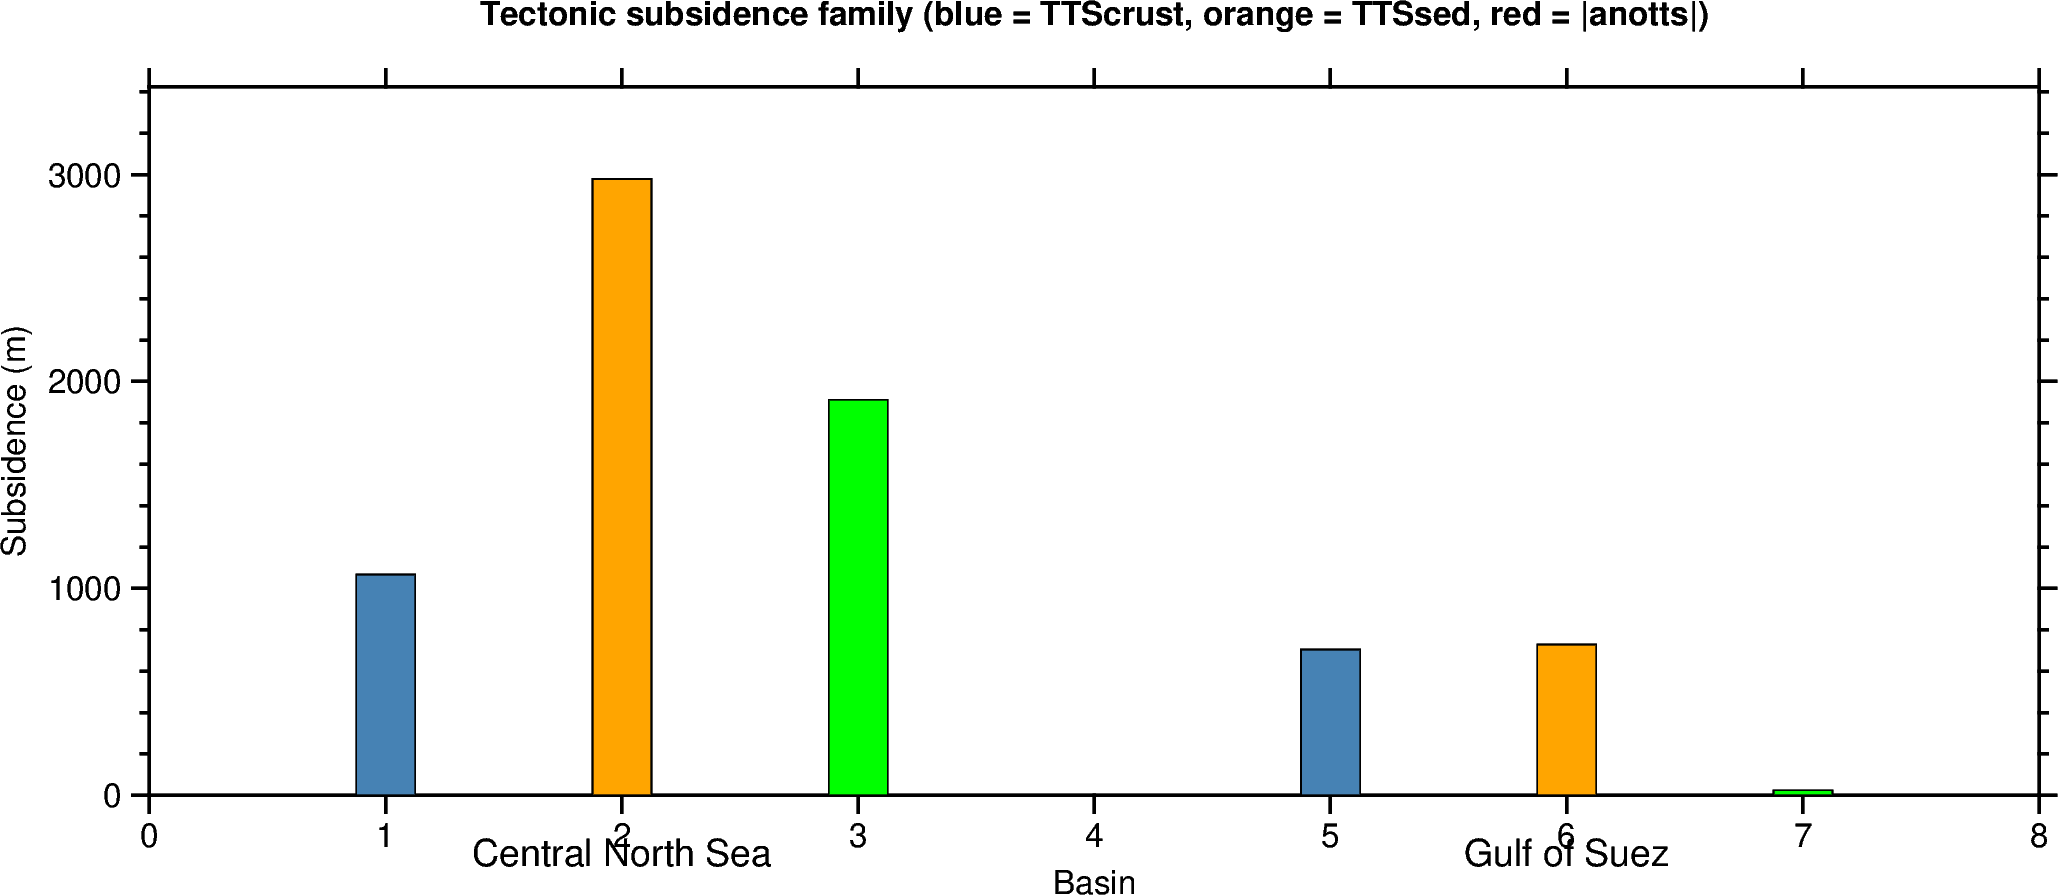

In [10]:
# --- Top: β family per basin ---
n = len(params_df)
x_pos_c = np.arange(1, n * 4, 4)     # positions for βcrust bars
x_pos_s = x_pos_c + 1                 # βsed
x_pos_d = x_pos_c + 2                 # diffbeta (relative)

y_max = max(params_df[["beta_crust", "beta_sed"]].max().max() * 1.15, 2.5)
fig = pygmt.Figure()
fig.basemap(region=[0, n * 4, 0, y_max],
            projection="X16c/6c",
            frame=["WSne+tβ family per basin (blue = βcrust, orange = βsed, red = |diffbeta| stacked at βcrust)",
                   "xa1+lBasin",
                   "yaf+lβ (dimensionless)"])
# Vertical bars using style=b<width>c
for i, r_ in params_df.iterrows():
    fig.plot(x=[x_pos_c[i]], y=[r_.beta_crust], style="b0.5c",
             fill="steelblue", pen="0.3p,black")
    fig.plot(x=[x_pos_s[i]], y=[r_.beta_sed],  style="b0.5c",
             fill="orange",    pen="0.3p,black")
    # diffbeta = beta_sed - beta_crust — show as green if positive, red if negative
    _col = "green" if r_.diffbeta >= 0 else "red"
    fig.plot(x=[x_pos_d[i]], y=[abs(r_.diffbeta)], style="b0.5c",
             fill=_col, pen="0.3p,black")
    fig.text(x=x_pos_c[i] + 1, y=-y_max * 0.08,
             text=r_.basin[:20],
             justify="MC", font="9p,Helvetica,black", no_clip=True)
fig.show(width=1000)

# --- Bottom: TTS family per basin ---
y_max = max(params_df[["tts_crust_m", "tts_sed_m"]].max().max() * 1.15, 500)
fig = pygmt.Figure()
fig.basemap(region=[0, n * 4, 0, y_max],
            projection="X16c/6c",
            frame=["WSne+tTectonic subsidence family (blue = TTScrust, orange = TTSsed, red = |anotts|)",
                   "xa1+lBasin",
                   "yaf+lSubsidence (m)"])
for i, r_ in params_df.iterrows():
    fig.plot(x=[x_pos_c[i]], y=[r_.tts_crust_m], style="b0.5c",
             fill="steelblue", pen="0.3p,black")
    fig.plot(x=[x_pos_s[i]], y=[r_.tts_sed_m],  style="b0.5c",
             fill="orange",    pen="0.3p,black")
    _col = "green" if r_.anotts_m >= 0 else "red"
    fig.plot(x=[x_pos_d[i]], y=[abs(r_.anotts_m)], style="b0.5c",
             fill=_col, pen="0.3p,black")
    fig.text(x=x_pos_c[i] + 1, y=-y_max * 0.08,
             text=r_.basin[:20],
             justify="MC", font="9p,Helvetica,black", no_clip=True)
fig.show(width=1000)


### How to read the extended parameter set

- **βcrust > βsed** — the basin's crust is more thinned than the sediment loading requires. Explanation: post-rift sediment starvation (sediment supply couldn't keep up with thermal subsidence), pre-rift crustal thinness for other reasons, or βcrust overestimated because the reference `T_C0_KM = 32 km` is too large for this crustal type.
- **βsed > βcrust** (`diffbeta > 0`, `anotts > 0`) — the sediment record demands more subsidence than crustal thinning alone provides. Classic signal of either (a) **mantle dynamic-topography subsidence**, or (b) **depth-dependent stretching** (mantle β > crustal β, thinning the mantle more than the crust). This is the case Rowley-Xie style two-layer models were designed to address.
- **Large `anotts` in old rifts** (Central Graben, 155 Ma) — thermal subsidence has had time to accumulate. Compare against the McKenzie-predicted post-rift subsidence in §5.
- **Small `anotts` in young rifts** (Gulf of Suez, 25 Ma) — no time yet for post-rift subsidence; the observed sediment is almost entirely syn-rift.


## 7. Paleogeographic reconstruction — where were these basins at their rift age?

Each basin's outline reconstructed to its own rift_age_ma via GPlately + Merdith 2021. Two paleo maps back-to-back — one per case study — coloured red for the reconstructed polygon.


  PlatePartitioner ready with 2391 static polygons
  423 rift-family basins in the Evenick (2021) compilation
  assigning plate IDs to basin centroids...
  0 of 423 basins fell back to plate 0 (true stationary — should be tiny fraction)


/Users/dietmar/tmp/ipykernel_71334/2908869825.py:55: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

/Users/dietmar/tmp/ipykernel_71334/2908869825.py:56: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



  369 / 423 rift-family basin centroids on paleo-continental crust at 155 Ma (dropped offshore/oceanic-crust basins from backdrop)
  case study Central Graben: 44 of 44 polygon vertices reconstructed


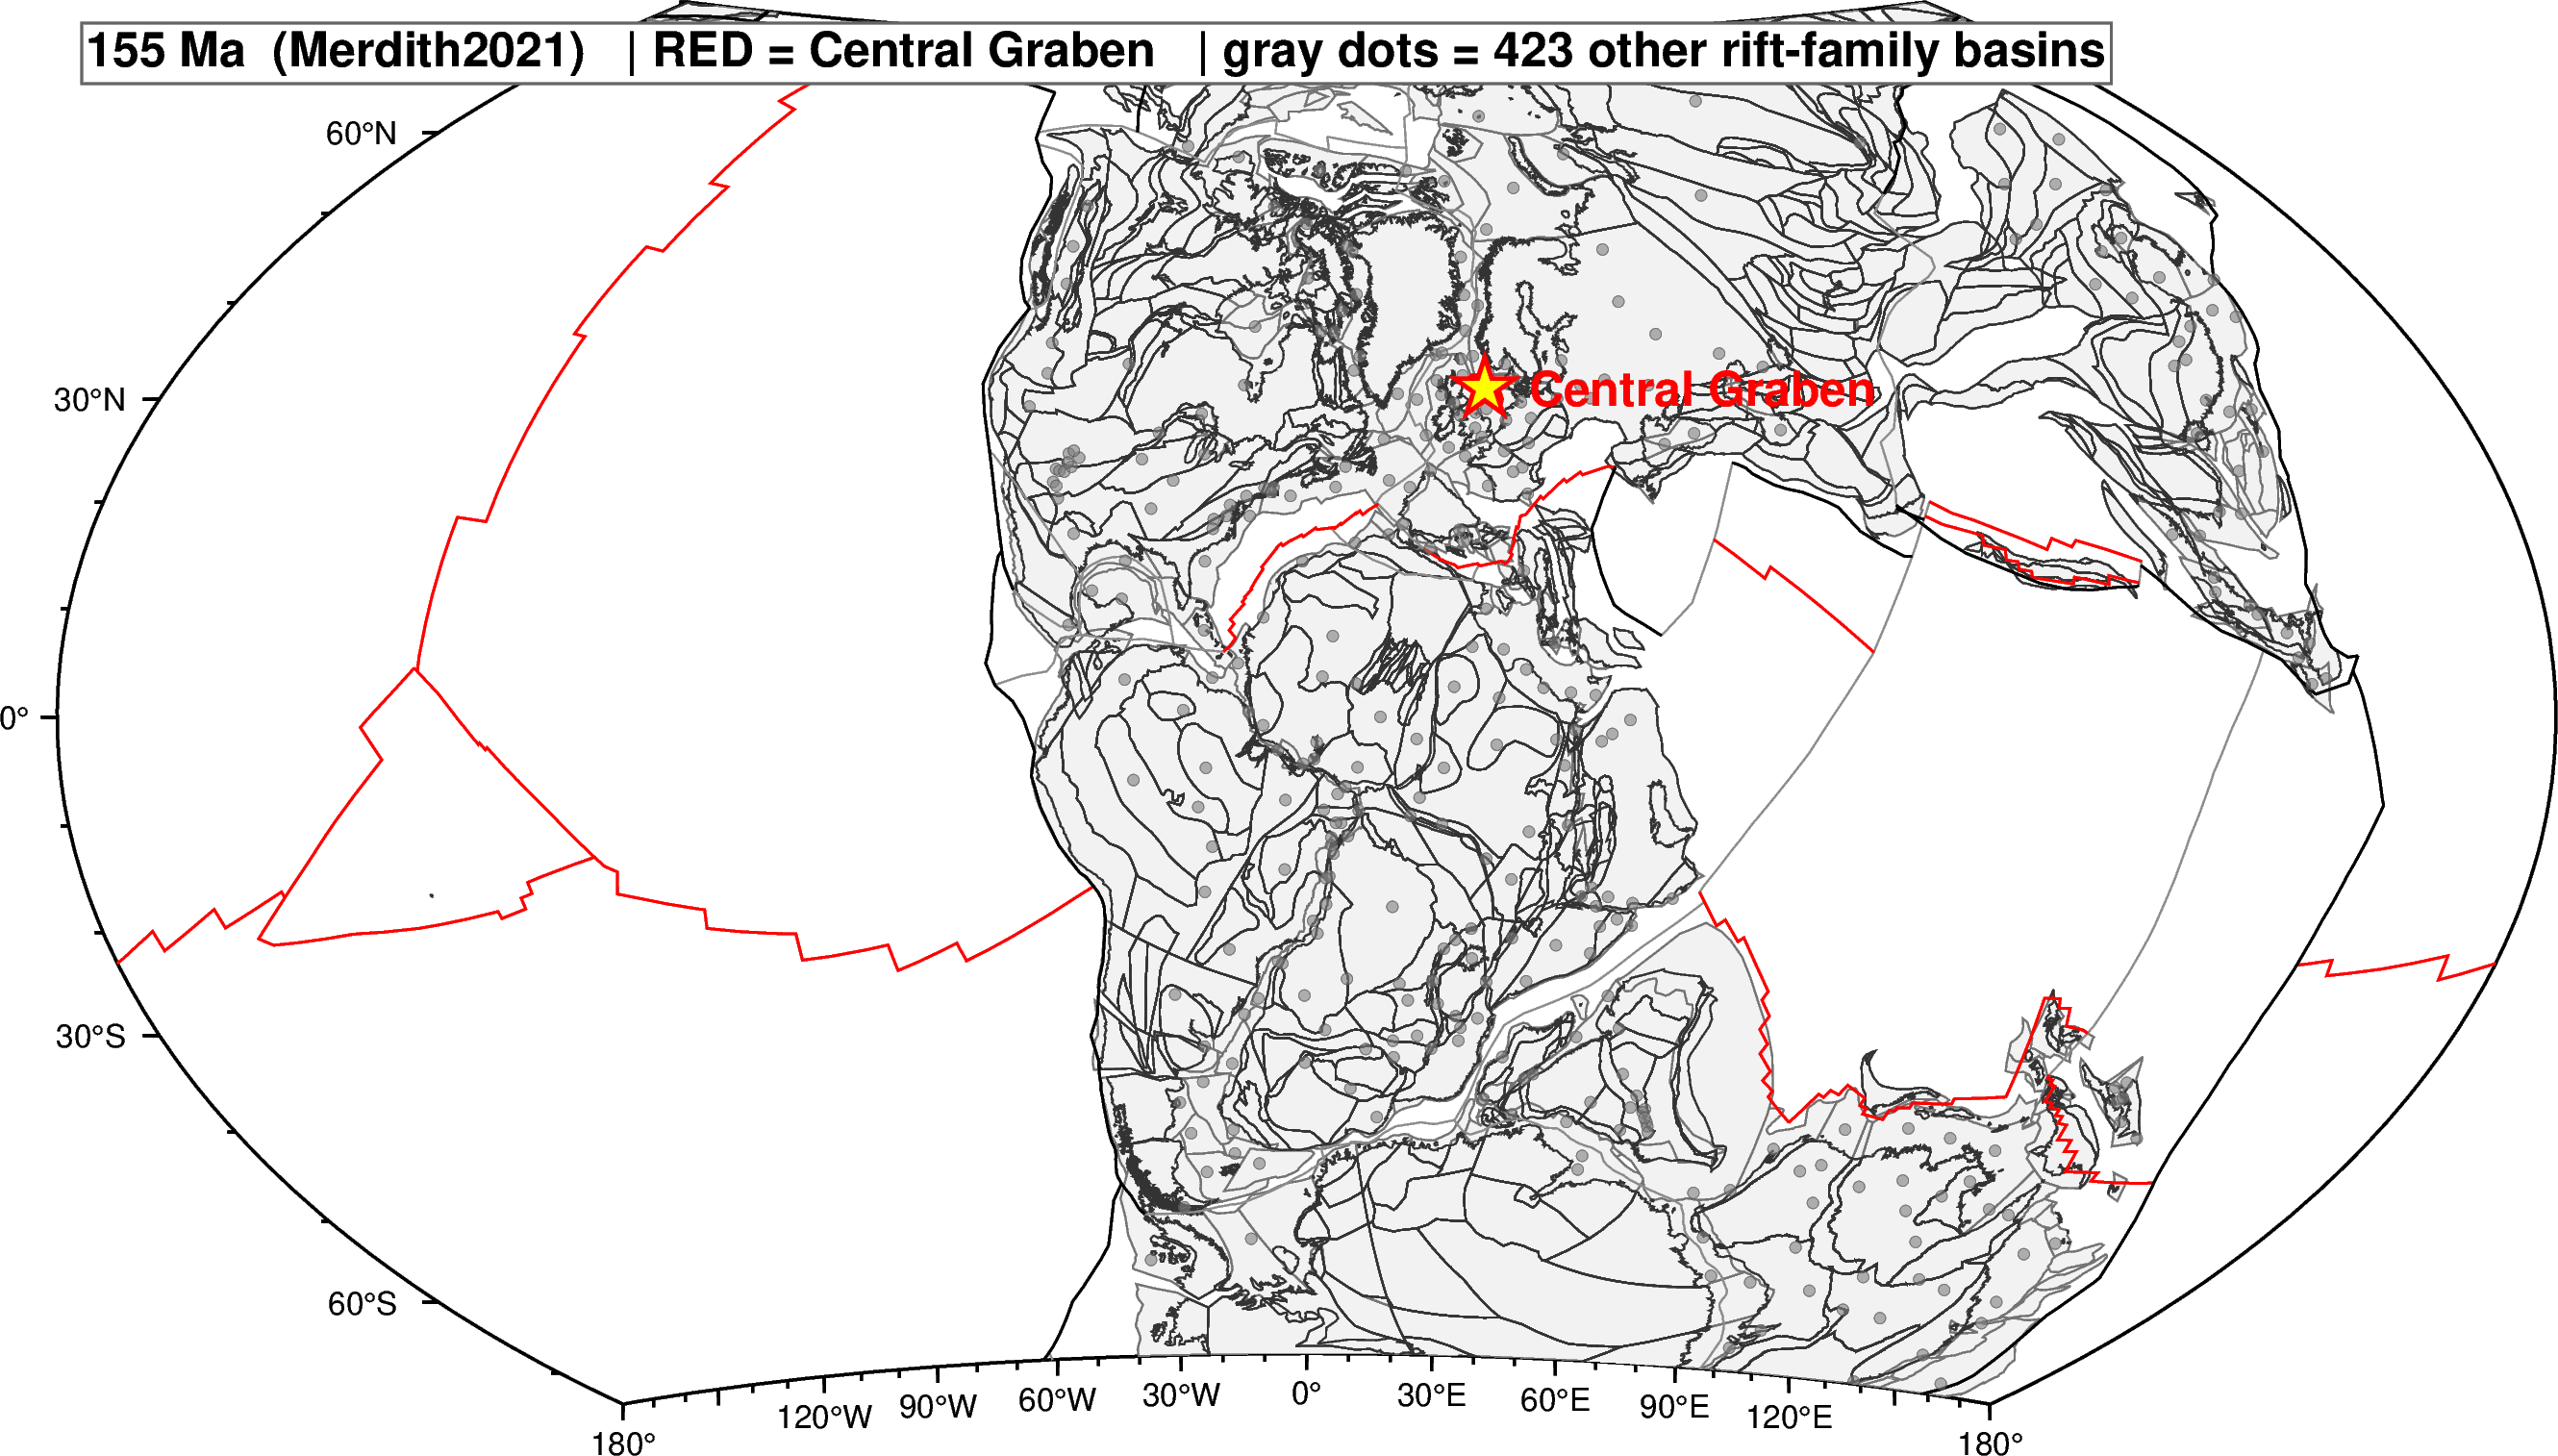

  404 / 423 rift-family basin centroids on paleo-continental crust at 25 Ma (dropped offshore/oceanic-crust basins from backdrop)
  case study Gulf of Suez: 30 of 30 polygon vertices reconstructed


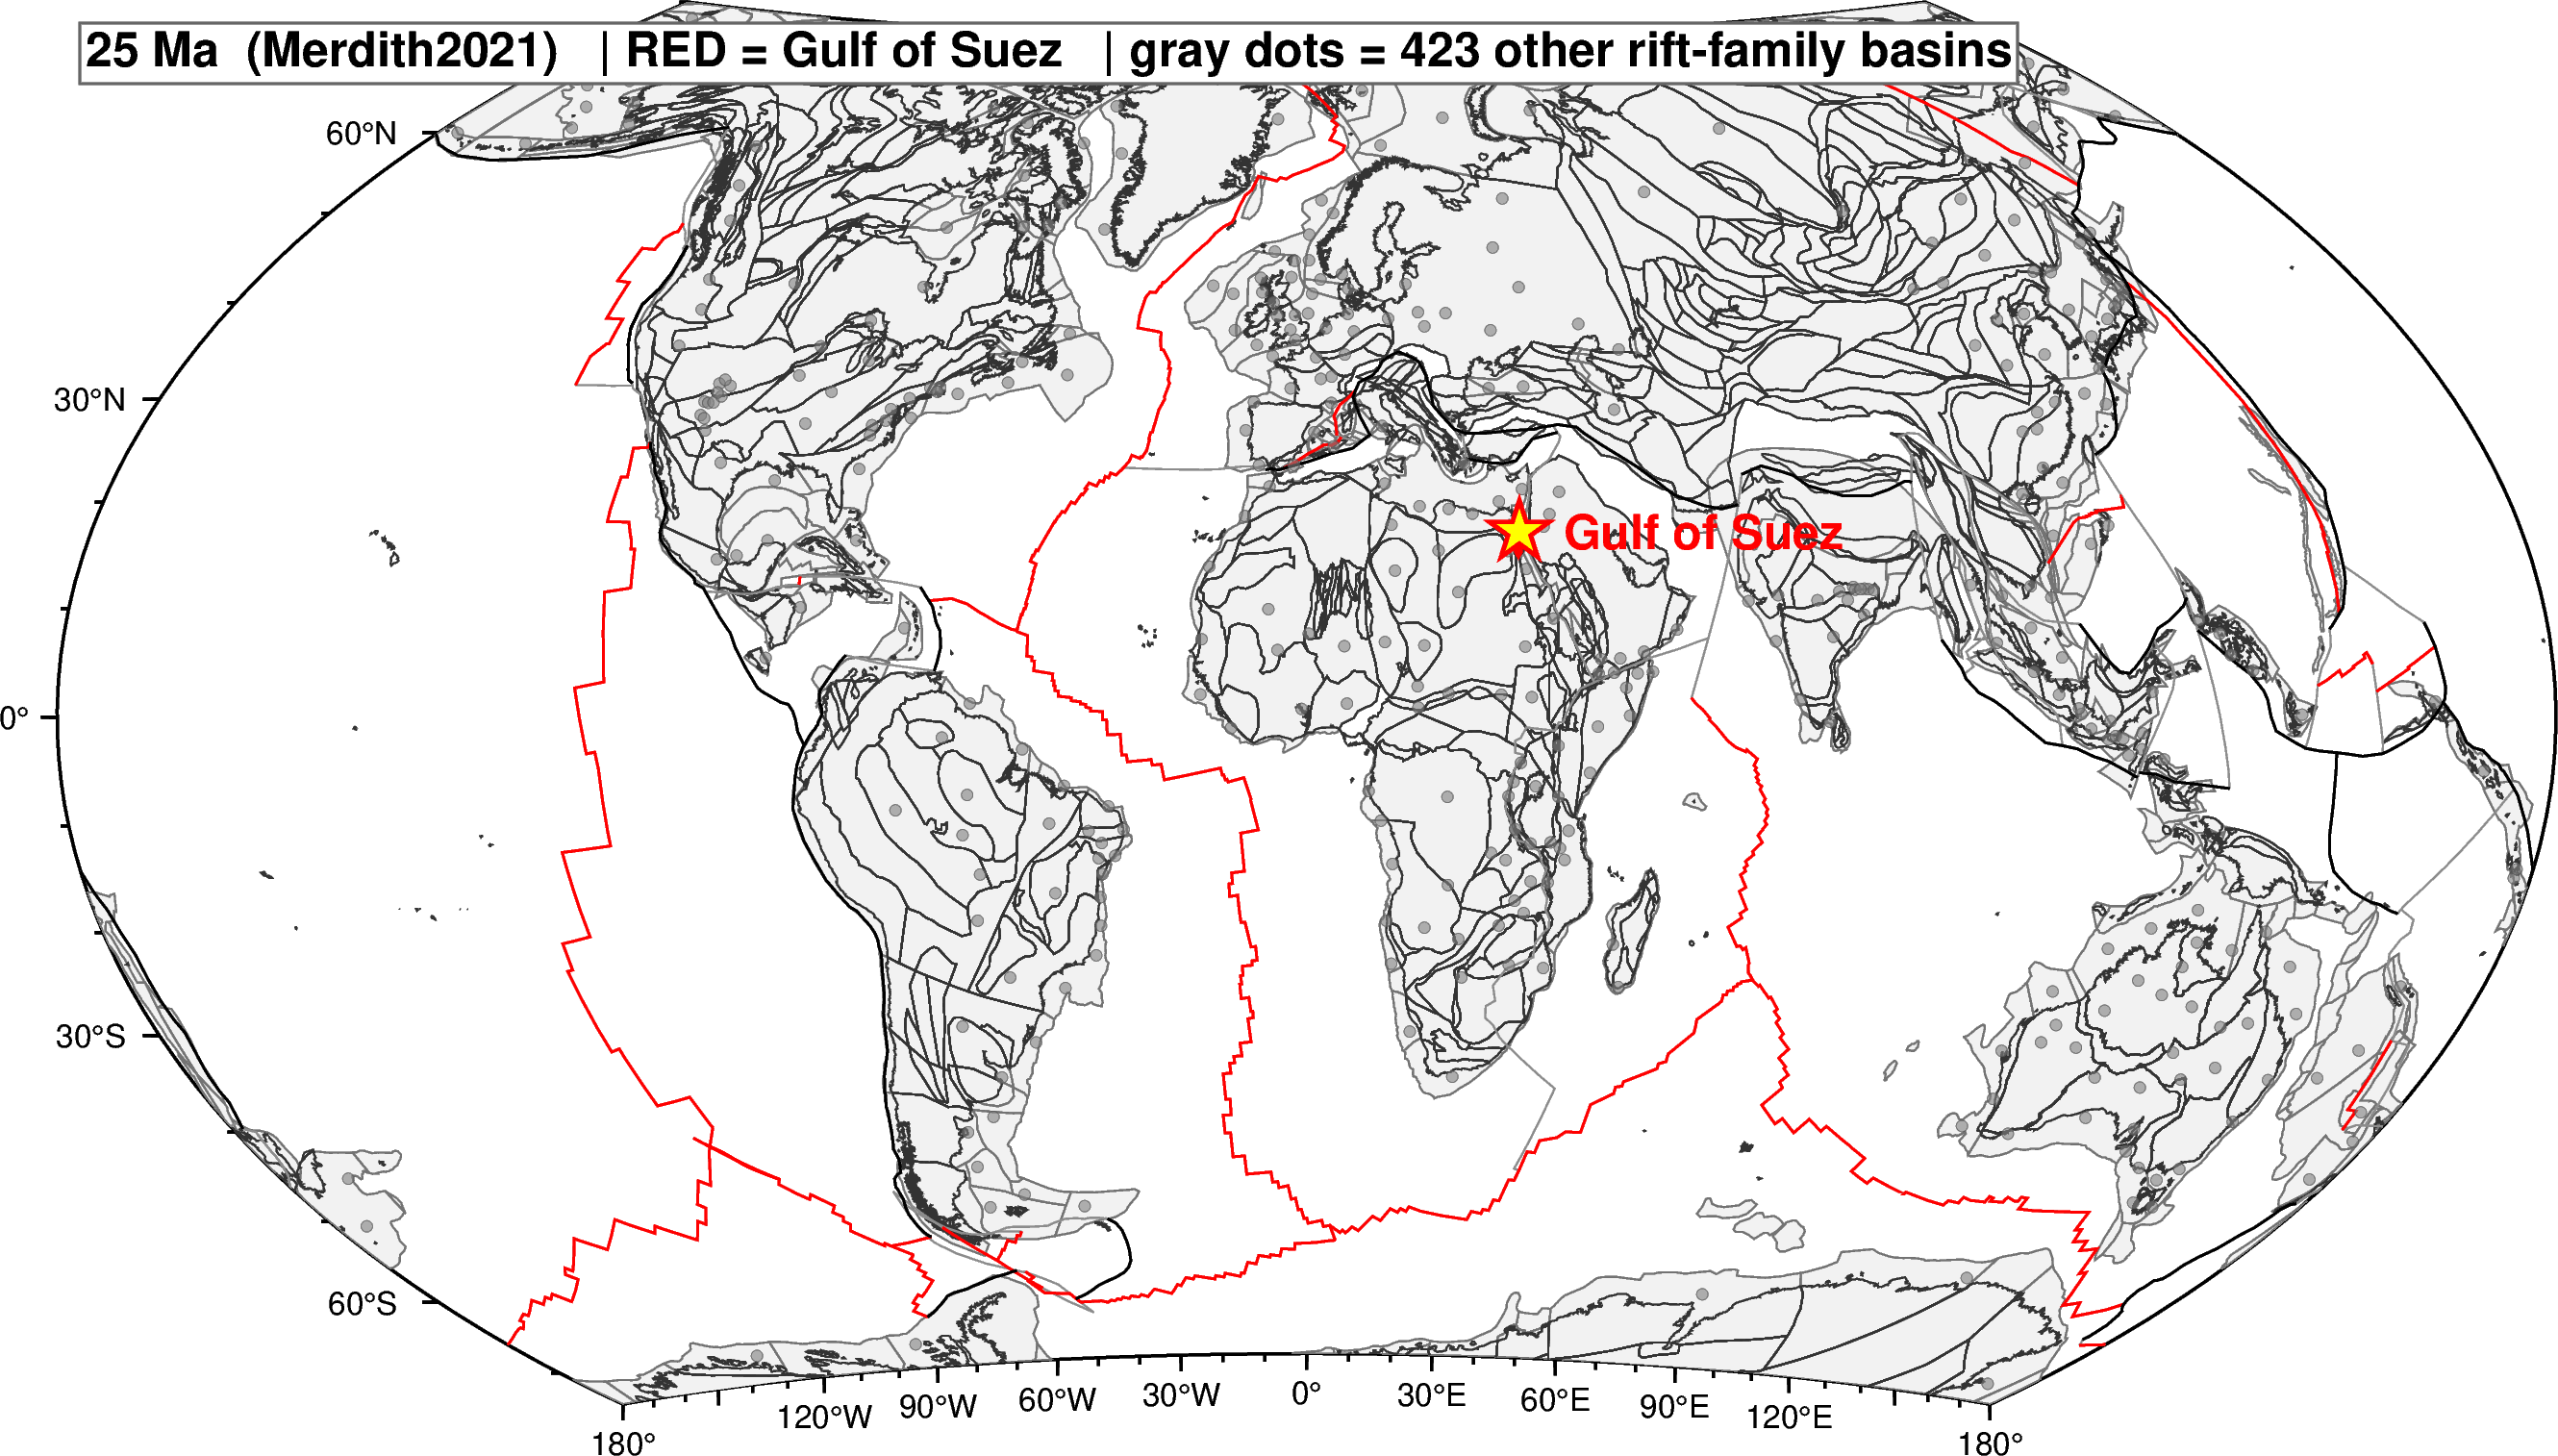

In [11]:
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="data/pmm_cache")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)

# ----------------------------------------------------------------------------
# Plate-ID assignment — canonical GPlates PlatePartitioner over StaticPolygons.
#
# Merdith 2021 has 850 continental-only polygons but 2391 STATIC polygons that
# cover the entire globe (including rifted-margin and oceanic segments). Using
# ContinentalPolygons alone leaves offshore basins with pid=None — they end
# up either unrotated (visually "floating in the ocean at reconstruction age")
# or forced onto a distant continental terrane by a nearest-boundary fallback.
#
# StaticPolygons + PlatePartitioner is the canonical GPlates approach. Every
# point on Earth resolves to a well-defined plate ID under the Merdith
# rotation model, and offshore basins ride the appropriate margin/oceanic
# plate with the correct paleo-position.
# ----------------------------------------------------------------------------
_static_features = list(pygplates.FeaturesFunctionArgument(
    model.get_static_polygons()).get_features())
_rotation_model  = pygplates.RotationModel(model.get_rotation_model())
_partitioner     = pygplates.PlatePartitioner(_static_features, _rotation_model)
print(f"  PlatePartitioner ready with {len(_static_features)} static polygons")

def assign_plate_ids(lons, lats):
    """Return int array of plate IDs from the Merdith static-polygon
    partition. Any point that fails to partition (extremely rare — poles
    only) gets pid=0 which stays fixed under any rotation."""
    pids = np.zeros(len(lons), dtype=int)
    for i, (lon, lat) in enumerate(zip(lons, lats)):
        pt = pygplates.PointOnSphere(float(lat), float(lon))
        partitioning_plate = _partitioner.partition_point(pt)
        if partitioning_plate is not None:
            pids[i] = int(partitioning_plate.get_feature().get_reconstruction_plate_id())
    return pids

# ---------------------------------------------------------------------------
# Backdrop: reconstruct centroids of ALL rift-family basins
# ---------------------------------------------------------------------------
# This is the extensional-basin subset of Evenick (2021)'s "Basin Type"
# vocabulary: actively or formerly rifted basin types (leaves out
# Strike-Slip, Foreland, Forearc, Fold and Thrust Belt, which aren't
# primarily extensional).
RIFT_FAMILY = [
    "Rift",
    "Passive Margin",
    "Intracratonic",
    "Backarc - Marginal Sea",
]
rift_basins = basins[basins["Basin Type"].isin(RIFT_FAMILY)].copy()
rift_basins["cent_lon"] = rift_basins.geometry.centroid.x
rift_basins["cent_lat"] = rift_basins.geometry.centroid.y
print(f"  {len(rift_basins)} rift-family basins in the Evenick (2021) compilation")
print(f"  assigning plate IDs to basin centroids...")
rift_basins["plate_id"] = assign_plate_ids(
    rift_basins["cent_lon"].to_numpy(), rift_basins["cent_lat"].to_numpy())
_n_zero = int((rift_basins["plate_id"] == 0).sum())
print(f"  {_n_zero} of {len(rift_basins)} basins fell back to plate 0 "
      f"(true stationary — should be tiny fraction)")

for r in results:
    case, basin = r["case"], r["basin"]
    age = float(case["rift_age_ma"])

    # -------- Rift-family backdrop, plate-ID reconstructed --------
    gpts_all = gplately.Points(
        recon,
        rift_basins["cent_lon"].to_numpy(),
        rift_basins["cent_lat"].to_numpy(),
        plate_id=rift_basins["plate_id"].to_numpy(),
        anchor_plate_id=ANCHOR_PLATE_ID,
    )
    ra_lons, ra_lats = gpts_all.reconstruct(
        age, return_array=True, anchor_plate_id=ANCHOR_PLATE_ID)
    _mask_ra = np.isfinite(ra_lons) & np.isfinite(ra_lats)

    # ---- Drop backdrop basins that land in the open ocean at this age ----
    # (their reconstruction is technically correct — some rift basins DID
    # form on nascent oceanic crust — but showing them as bare dots over
    # blue ocean reads as "reconstruction failed". We restrict the backdrop
    # to basins whose paleo-position sits inside a reconstructed
    # continental polygon, which is what the reader expects visually.)
    _cont_recon_at_age = []
    _cf = list(pygplates.FeaturesFunctionArgument(
        model.get_layer("ContinentalPolygons")).get_features())
    _rr = []
    pygplates.reconstruct(_cf, _rotation_model, _rr, float(age),
                          anchor_plate_id=ANCHOR_PLATE_ID)
    for _r in _rr:
        _g = _r.get_reconstructed_geometry()
        if isinstance(_g, pygplates.PolygonOnSphere):
            _cont_recon_at_age.append(_g)
    _on_land = np.zeros(len(ra_lons), dtype=bool)
    for _i, (_lo, _la) in enumerate(zip(ra_lons, ra_lats)):
        if not (_mask_ra[_i]):
            continue
        _pt = pygplates.PointOnSphere(float(_la), float(_lo))
        for _pg in _cont_recon_at_age:
            if _pg.is_point_in_polygon(_pt):
                _on_land[_i] = True; break
    _mask_ra = _mask_ra & _on_land
    print(f"  {int(_mask_ra.sum())} / {len(rift_basins)} rift-family basin "
          f"centroids on paleo-continental crust at {age:.0f} Ma "
          f"(dropped offshore/oceanic-crust basins from backdrop)")

    # -------- Case-study basin polygon (per-vertex plate IDs) --------
    g = basin.geometry
    parts = g.geoms if g.geom_type == "MultiPolygon" else [g]
    reconstructed_parts = []
    for part in parts:
        xs = np.array(list(part.exterior.xy[0]))
        ys = np.array(list(part.exterior.xy[1]))
        vpids = assign_plate_ids(xs, ys)
        gpts_p = gplately.Points(recon, xs, ys, plate_id=vpids,
                                  anchor_plate_id=ANCHOR_PLATE_ID)
        rlons, rlats = gpts_p.reconstruct(age, return_array=True,
                                           anchor_plate_id=ANCHOR_PLATE_ID)
        mask = np.isfinite(rlons) & np.isfinite(rlats)
        if mask.sum() >= 3:
            reconstructed_parts.append((rlons[mask], rlats[mask]))
    print(f"  case study {case['name']}: {sum(len(p[0]) for p in reconstructed_parts)} "
          f"of {sum(len(part.exterior.xy[0]) for part in parts)} polygon vertices reconstructed")

    # -------- Paleo base map --------
    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_layer("Coastlines"),
        continents=model.get_layer("ContinentalPolygons"),
        plot_engine=gplately.PygmtPlotEngine(),
        time=age,
        anchor_plate_id=ANCHOR_PLATE_ID,
    )
    fig = pygmt.Figure()
    fig.basemap(region=GLOBAL_REGION, projection=GLOBAL_PROJ, frame="af")
    gplot.plot_continents(fig, fill="gray95", pen="0.4p,gray45")
    gplot.plot_coastlines(fig, pen="0.4p,gray20")
    try:
        gplot.plot_all_topological_sections(fig, pen="0.4p,gray55")
        gplot.plot_ridges(fig, pen="0.6p,red")
        gplot.plot_trenches(fig, pen="0.6p,black")
    except Exception as _e:
        print(f"    topology overlay skipped: {_e}")

    # Layer 1: rift-family backdrop, faint gray dots (properly reconstructed)
    fig.plot(x=ra_lons[_mask_ra], y=ra_lats[_mask_ra],
             style="c0.10c", fill="gray50", pen="0.15p,gray30", transparency=40)

    # Layer 2: case-study polygon in bright red
    for rlons, rlats in reconstructed_parts:
        fig.plot(x=list(rlons), y=list(rlats),
                 fill="red@30", pen="1.5p,red", close=True)
    # Star at reconstructed centroid + label
    _c_lon = float(basin.geometry.centroid.x)
    _c_lat = float(basin.geometry.centroid.y)
    _c_pid = int(assign_plate_ids(np.array([_c_lon]), np.array([_c_lat]))[0])
    _gp_c = gplately.Points(recon, np.array([_c_lon]), np.array([_c_lat]),
                            plate_id=np.array([_c_pid]),
                            anchor_plate_id=ANCHOR_PLATE_ID)
    _rc_lons, _rc_lats = _gp_c.reconstruct(age, return_array=True,
                                            anchor_plate_id=ANCHOR_PLATE_ID)
    if np.isfinite(_rc_lons[0]) and np.isfinite(_rc_lats[0]):
        fig.plot(x=_rc_lons, y=_rc_lats, style="a0.55c",
                 fill="yellow", pen="1p,red")
        fig.text(x=float(_rc_lons[0]), y=float(_rc_lats[0]),
                 text=f"  {case['name']}", justify="ML", offset="0.15c/0c",
                 font="12p,Helvetica-Bold,red")

    fig.text(text=f"{age:.0f} Ma  ({MODEL_NAME})   "
                  f"| RED = {case['name']}   "
                  f"| gray dots = {len(rift_basins)} other rift-family basins",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="12p,Helvetica-Bold,black", fill="white", pen="0.6p,gray40")
    fig.show(width=1000)


## Extend this

- **Add more basins.** Extend the `CASE_STUDIES` list with any Evenick (2021) basin name and a suitable rift age + transect. Good next candidates: **Rhine Graben** (\~35 Ma), **Baikal Rift** (\~30 Ma), **North Falkland Basin** (\~140 Ma), **Sirt Basin** (Libya, \~100 Ma), **East Greenland Basins** (\~55 Ma) — check the exact `Basin Name` string in the shapefile first (see T53 §1 for the full column list), and set `shapefile_name` if it differs from the display name you want to use, the way this notebook does for "Central Graben" → `"Central North Sea"`.
- **Real seismic-based wedge fitting.** The wedge + drape decomposition here is a first-order shape fit. A real syn-/post-rift analysis needs picked stratigraphic surfaces from seismic-reflection data (rift onset unconformity, rift-drift unconformity). Extend by loading a picked stratigraphic horizon from a public dataset (e.g. the Bureau of Economic Geology Central Graben interpretations) and fitting the wedge to that instead of total Bird & Mooney thickness.
- **Backstrip to tectonic subsidence.** The observed total sediment thickness is filled subsidence, not tectonic subsidence. Add a `pyBacktrack` call to decompact + isostatically correct the observed column and compare the tectonic-subsidence portion to the McKenzie prediction.
- **Depth-dependent stretching.** McKenzie 1978 assumes pure shear (crust + mantle stretch equally, β = δ). Replace `initial_subsidence` + `thermal_subsidence` with a Rowley-Xie style depth-dependent formulation (β for crust, δ for mantle lithosphere) and refit both parameters — a two-layer model often fits the observed data better for hyper-extended margins.
- **Compare to T14 rift-obliquity output.** T14 computes per-segment obliquity along active rift boundaries. Overlay the T14 obliquity along each basin's paleo-rift lines to test whether the basin's syn-rift wedge asymmetry correlates with the segment obliquity — orthogonal rifts should give more symmetric wedges.
- **Compute paleo-water-depth history.** Combine the McKenzie subsidence prediction with the observed sediment thickness to solve for paleo-water-depth as a function of time, exposing basin evolution from lacustrine → marine → deep-marine.
- **Cross-reference the evaporite record.** T53 §7 joins Evenick's evaporite-occurrence spreadsheet — check whether either case-study basin has a dated evaporite phase near its rift age, which would independently corroborate the basin's restricted, actively-subsiding early history.

## Related notebooks

- **T53** — Global basin inventory (Evenick 2021). Same shapefile, same sediment + crustal-thickness grids, global view.
- **T54** — Global β-factor field. Same crustal-thickness input, McKenzie β applied globally rather than at a chosen basin's centroid.
- **T14** — Rift obliquity through time (Brune-based). Different data type (plate topologies not basins) but shares the extensional-tectonics theme.
- **T12** — Retrodeforming a global lithospheric-thickness grid. Complementary — T55 is a per-basin subsidence view, T12 is a per-plate lithospheric thickness view.

## References

- Evenick, J.C. (2021). Glimpses into Earth's history using a revised global sedimentary basin map. *Earth-Science Reviews* 215, 103564. https://doi.org/10.1016/j.earscirev.2021.103564 — source of the two case-study basin polygons (CC BY-NC-ND 4.0, redistributed verbatim; see `data/evenick_2021_basins/README.md`).
- McKenzie, D. (1978). Some remarks on the development of sedimentary basins. *Earth and Planetary Science Letters* 40, 25-32.
- Sclater, J.G. & Christie, P.A.F. (1980). Continental stretching: An explanation of the post-Mid-Cretaceous subsidence of the central North Sea Basin. *Journal of Geophysical Research: Solid Earth* 85(B7), 3711-3739.
- Rowley, D.B. & Sahagian, D.L. (1986). Depth-dependent stretching: A different approach. *Geology* 14(1), 32-35.
- Bird, D.E. & Mooney, W.D. (2026). GST-1: A high-resolution global sediment thickness model. *Tectonophysics*, p.231175.
- Afonso, J.C., et al. (2019). A global reference model of the lithosphere and upper mantle. *Geophysical Journal International* 217, 1602-1628. https://doi.org/10.1093/gji/ggz094
- Bosworth, W., Huchon, P. & McClay, K. (2005). The Red Sea and Gulf of Aden Basins. *Journal of African Earth Sciences* 43, 334-378 — canonical Gulf of Suez rift review.
- Zanella, E. & Coward, M.P. (2003). Structural framework. In: *The Millennium Atlas: Petroleum Geology of the Central and Northern North Sea* (eds. Evans, D., Graham, C., Armour, A. & Bathurst, P.), Geological Society, London.
- Merdith, A.S., et al. (2021). Extending full-plate tectonic models into deep time. *Earth-Science Reviews* 214, 103477.
- ICONS Atlas (live resource, EarthByte Group, University of Sydney) — original basin-polygon infrastructure this notebook's workflow descends from: https://www.earthbyte.org/Resources/ICONS/
